# Alternative 3: 25 m hydrological connectivity (Mole Creek)

This notebook applies the existing 2 m WhiteboxTools flow-accumulation method to the prepared 25 m Mole Creek DEM. It uses mapped LIST Watercourses to assess a flow-accumulation threshold and derive a binary drainage network, then creates a binary `KPROXCATCH` mask.

The DEM is filled with WhiteboxTools `FillDepressions`, then processed with D8 flow accumulation in cell counts. Watercourses are not burned into the DEM in this workflow; their raster mask is used afterward for threshold comparison. A D8 pointer raster is also saved on the same grid for later routing-count work. This notebook does not perform those counts.

All output names include `25m` and `alt3` to keep them separate from existing 2 m and other workflow outputs. The notebook contains code and explanations only; run the cells when ready.


## 1. Set paths and check the 25 m inputs

Resolve the project data directory, identify the existing Mole Creek DEM, the statewide Watercourse GeoPackage, and the Karst Atlas GeoPackage. Check the DEM CRS, resolution, extent, and valid-data mask before using it as the grid template. The prepared Watercourse GeoPackage must have been created in `03alt_hydrological_connectivity`.


In [2]:
from pathlib import Path
import os
import shutil

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from rasterio.features import rasterize
from rasterio.enums import Resampling
from rasterio.windows import Window

# Resolve the project root and data directory using the same convention as 03alt2.
working_dir = Path.cwd()
project_root = working_dir.parent if working_dir.name == "notebooks" else working_dir
data_dir_value = os.environ.get("AT3_DATA_DIR")
if not data_dir_value:
    env_file = project_root / ".env"
    if env_file.exists():
        for line in env_file.read_text(encoding="utf-8-sig").splitlines():
            entry = line.strip()
            if entry.startswith("AT3_DATA_DIR="):
                data_dir_value = entry.split("=", 1)[1].strip().strip('"').strip("'")
                break

data_path = Path(data_dir_value).expanduser() if data_dir_value else project_root / "data"
if not data_path.is_absolute():
    data_path = (project_root / data_path).resolve()
input_path = data_path / "Input_data"
output_path = data_path / "Output_data"

dem_25m_path = output_path / "dem_mc_EPSG7855.tif"
watercourse_gpkg_path = output_path / "watercourses_tas_EPSG7855.gpkg"
karst_atlas_path = output_path / "karst_mc_susceptibility_EPSG7855.gpkg"

# Distinct outputs for this 25 m workflow.
wbt_dem_25m_path = output_path / "dem_mc_25m_wbt_EPSG7855_alt3.tif"
filled_dem_25m_path = output_path / "dem_mc_25m_filled_EPSG7855_alt3.tif"
flow_accumulation_25m_path = output_path / "flow_accum_mc_25m_EPSG7855_alt3.tif"
d8_pointer_25m_path = output_path / "d8_pointer_mc_25m_EPSG7855_alt3.tif"
watercourse_presence_25m_path = output_path / "watercourse_presence_mc_25m_EPSG7855_alt3.tif"
drainage_network_25m_path = output_path / "drainage_network_mc_25m_EPSG7855_alt3.tif"
threshold_report_25m_path = output_path / "flowacc_watercourse_threshold_mc_25m_EPSG7855_alt3.csv"
kprox_presence_25m_path = output_path / "kproxcatch_presence_mc_25m_EPSG7855_alt3.tif"

for required_path in (dem_25m_path, watercourse_gpkg_path, karst_atlas_path):
    if not required_path.is_file():
        raise FileNotFoundError(f"Required input not found: {required_path}")

with rasterio.open(dem_25m_path) as dem_src:
    if dem_src.count != 1:
        raise ValueError(f"Expected a single-band 25 m DEM: {dem_25m_path}")
    if dem_src.crs is None or dem_src.crs.to_epsg() != 7855:
        raise ValueError(f"Expected the DEM in EPSG:7855; found {dem_src.crs}")
    if not np.allclose(dem_src.res, (25.0, 25.0), rtol=0, atol=1e-6):
        raise ValueError(f"Expected 25 m DEM cells; found resolution {dem_src.res}")
    dem_grid = (dem_src.shape, dem_src.crs, dem_src.transform, dem_src.res)
    dem_bounds = dem_src.bounds
    dem_profile = dem_src.profile.copy()
    dem_nodata = dem_src.nodata
    valid_dem = dem_src.dataset_mask() > 0
    dem_values = dem_src.read(1, masked=True)
    valid_dem &= ~np.ma.getmaskarray(dem_values) & np.isfinite(dem_values.data)

if not valid_dem.any():
    raise ValueError("The 25 m DEM contains no valid elevation cells")

print(f"25 m DEM: {dem_25m_path}")
print(f"CRS: {dem_grid[1]}; shape: {dem_grid[0]}; resolution: {dem_grid[3]}")
print(f"Bounds: {dem_bounds}; valid cells: {int(valid_dem.sum()):,}")
print(f"Output directory: {output_path}")


25 m DEM: C:\Users\innoc\OneDrive - University of Tasmania\AT3_initial_datasets\Output_data\dem_mc_EPSG7855.tif
CRS: EPSG:7855; shape: (1599, 2178); resolution: (25.00000006237901, 25.00000006237901)
Bounds: BoundingBox(left=427075.3867283147, bottom=5370551.485804868, right=481525.38686417614, top=5410526.485904612); valid cells: 1,848,410
Output directory: C:\Users\innoc\OneDrive - University of Tasmania\AT3_initial_datasets\Output_data


## 2. Fill depressions and calculate 25 m D8 flow accumulation

Follow the 2 m workflow in `03alt2`: make a Whitebox-compatible copy of the DEM, run `FillDepressions`, then run `D8FlowAccumulation` with `out_type="cells"`. No Watercourse burning or other DEM conditioning is added here. Also create a Whitebox-native D8 pointer from the same filled DEM and validate that the filled DEM, accumulation, and pointer retain the exact input grid. The pointer is provided for later routing counts; this notebook does not calculate those counts.

Existing hydrology outputs are reused when all three match the source DEM grid and were produced by this cell version. If this cell changes or an output is missing or invalid, the three outputs are regenerated and replaced after successful validation.


In [ ]:
import whitebox
import hashlib
import json
from osgeo import gdal

wbt_dir = project_root / "WhiteboxTools_win_amd64" / "WBT"
wbt_exe = wbt_dir / "whitebox_tools.exe"
if not wbt_exe.is_file():
    raise FileNotFoundError(f"WhiteboxTools executable not found: {wbt_exe}")

# Point the Python wrapper at the repository's existing WhiteboxTools installation.
os.environ["WBT_PATH"] = str(wbt_dir)
wbt = whitebox.WhiteboxTools()
wbt.set_whitebox_dir(str(wbt_dir))
wbt.verbose = True
print(f"WhiteboxTools version: {wbt.version()}")

hydrology_outputs = (filled_dem_25m_path, flow_accumulation_25m_path, d8_pointer_25m_path)
hydrology_manifest_path = output_path / "hydrology_mc_25m_EPSG7855_alt3.cell.json"
try:
    running_cell_source = get_ipython().user_ns["In"][-1]
except (NameError, AttributeError, IndexError, KeyError):
    running_cell_source = "\n".join([
        "alt3-flow-code", str(dem_25m_path), str(filled_dem_25m_path),
        str(flow_accumulation_25m_path), str(d8_pointer_25m_path),
    ])
hydrology_source_hash = hashlib.sha256(running_cell_source.encode("utf-8")).hexdigest()

# Reuse a complete, grid-matching set if its recorded source matches this cell.
hydrology_outputs_valid = all(path.is_file() for path in hydrology_outputs)
if hydrology_outputs_valid:
    for result_path in hydrology_outputs:
        try:
            with rasterio.open(result_path) as result_src:
                result_grid = (result_src.shape, result_src.crs, result_src.transform, result_src.res)
            if result_grid != dem_grid:
                hydrology_outputs_valid = False
                break
        except Exception:
            hydrology_outputs_valid = False
            break

hydrology_saved_hash = None
if hydrology_manifest_path.is_file():
    try:
        hydrology_saved_hash = json.loads(hydrology_manifest_path.read_text(encoding="utf-8"))["source_sha256"]
    except (OSError, ValueError, KeyError, TypeError):
        hydrology_saved_hash = None
# Existing outputs without a manifest predate this check; treat them as the saved baseline.
hydrology_outputs_current = hydrology_outputs_valid and (
    hydrology_saved_hash in (None, hydrology_source_hash)
)

# WhiteboxTools expects a tiled Float32 input; retain the original DEM unchanged.
if not wbt_dem_25m_path.exists():
    compatible_dem = gdal.Translate(
        str(wbt_dem_25m_path),
        str(dem_25m_path),
        creationOptions=[
            "TILED=YES", "COMPRESS=DEFLATE", "PREDICTOR=1", "BIGTIFF=IF_SAFER",
        ],
    )
    if compatible_dem is None:
        raise RuntimeError("Could not create the Whitebox-compatible 25 m DEM copy")
    compatible_dem = None

with rasterio.open(wbt_dem_25m_path) as wbt_dem_src:
    if (wbt_dem_src.shape, wbt_dem_src.crs, wbt_dem_src.transform, wbt_dem_src.res) != dem_grid:
        raise ValueError("The Whitebox-compatible DEM copy does not match the source DEM grid")

if hydrology_outputs_current:
    print("Reusing existing 25 m hydrology outputs; this cell's source and DEM grid are unchanged.")
    if hydrology_saved_hash is None:
        hydrology_manifest_path.write_text(
            json.dumps({"source_sha256": hydrology_source_hash}, indent=2), encoding="utf-8"
        )
else:
    print("Hydrology outputs are missing, invalid, or from a changed cell; rebuilding them.")
    # Build to temporary files first so a failed run does not damage valid saved outputs.
    refresh_outputs = tuple(
        path.with_name(path.stem + ".refresh" + path.suffix) for path in hydrology_outputs
    )
    for temporary_path in refresh_outputs:
        if temporary_path.exists():
            temporary_path.unlink()

    wbt.set_working_dir(str(output_path))
    wbt.fill_depressions(str(wbt_dem_25m_path), str(refresh_outputs[0]))
    if not refresh_outputs[0].is_file():
        raise RuntimeError("WhiteboxTools FillDepressions did not create the temporary filled DEM")

    wbt.d8_flow_accumulation(
        str(refresh_outputs[0]), str(refresh_outputs[1]), out_type="cells",
    )
    if not refresh_outputs[1].is_file():
        raise RuntimeError("WhiteboxTools D8FlowAccumulation did not create the temporary accumulation raster")

    # Save the native Whitebox D8 pointer as a separate input for later routing counts.
    wbt.d8_pointer(str(refresh_outputs[0]), str(refresh_outputs[2]), esri_pntr=False)
    if not refresh_outputs[2].is_file():
        raise RuntimeError("WhiteboxTools D8Pointer did not create the temporary pointer raster")

    for label, temporary_path in zip(
        ("Filled DEM", "D8 flow accumulation", "Whitebox-native D8 pointer"), refresh_outputs
    ):
        with rasterio.open(temporary_path) as result_src:
            result_grid = (result_src.shape, result_src.crs, result_src.transform, result_src.res)
            if result_grid != dem_grid:
                raise ValueError(f"{label} does not match the exact 25 m DEM grid: {temporary_path}")

    for temporary_path, result_path in zip(refresh_outputs, hydrology_outputs):
        temporary_path.replace(result_path)
    hydrology_manifest_path.write_text(
        json.dumps({"source_sha256": hydrology_source_hash}, indent=2), encoding="utf-8"
    )

for label, result_path in zip(
    ("Filled DEM", "D8 flow accumulation", "Whitebox-native D8 pointer"), hydrology_outputs
):
    with rasterio.open(result_path) as result_src:
        result_grid = (result_src.shape, result_src.crs, result_src.transform, result_src.res)
        if result_grid != dem_grid:
            raise ValueError(f"{label} does not match the exact 25 m DEM grid: {result_path}")
        print(f"{label}: {result_path.name}; CRS {result_src.crs}; shape {result_src.shape}; resolution {result_src.res}; NoData {result_src.nodata}")


## 2.1 Calculate slope and map slope-based karst susceptibility

Calculate slope in degrees from the original 25 m Mole Creek DEM, then summarize the mean slope of valid DEM cells inside each Karst Atlas polygon. Reclassify each polygon's mean slope using the lookup table below and map the resulting susceptibility level. This is a polygon-level classification: the slope raster is summarized first, then each polygon receives one score.

| Mean slope range | Susceptibility level | Reclassified value |
|---|---|---:|
| 0 <= slope < 10 degrees | Very Low | 1 |
| 10 <= slope < 20 degrees | Low | 2 |
| 20 <= slope < 30 degrees | Moderate | 3 |
| 30 <= slope < 42 degrees | High | 4 |
| slope >= 42 degrees | Very High | 5 |

The raster, polygon table, and map are saved with `25m` and `alt3` in their names. The slope classes describe terrain steepness; they are a separate slope-based susceptibility layer and do not replace the Karst Atlas susceptibility classification.


Slope reclassification lookup:


,slope_range_degrees,susceptibility_level,reclassified_value
0,0 <= x < 10,Very Low,1
1,10 <= x < 20,Low,2
2,20 <= x < 30,Moderate,3
3,30 <= x < 42,High,4
4,x >= 42,Very High,5


Polygon slope table: C:\Users\innoc\OneDrive - University of Tasmania\AT3_initial_datasets\Output_data\karst_slope_susceptibility_mc_25m_EPSG7855_alt3.csv
Classified polygons: C:\Users\innoc\OneDrive - University of Tasmania\AT3_initial_datasets\Output_data\karst_slope_susceptibility_mc_25m_EPSG7855_alt3.gpkg
Polygon counts by slope susceptibility:


,susceptibility_level,polygon_count
0,Very Low,63
1,Low,27
2,Moderate,0
3,High,0
4,Very High,0


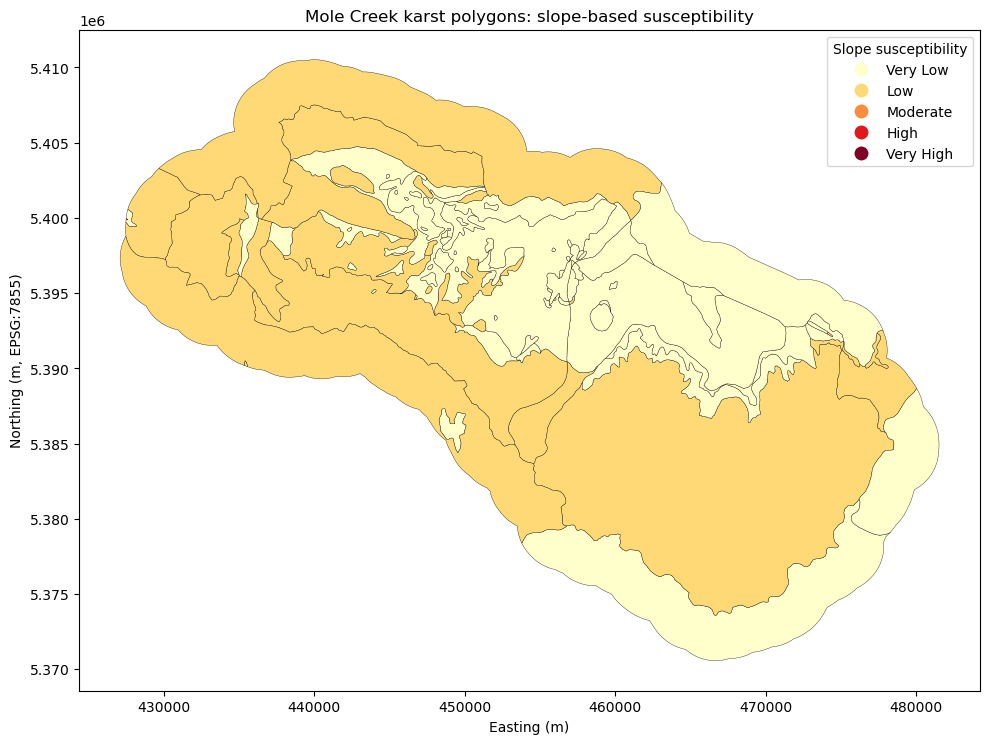

In [16]:
import whitebox
from rasterio.mask import mask as raster_mask
from IPython.display import display

slope_25m_path = output_path / "slope_mc_25m_EPSG7855_alt3.tif"
karst_slope_gpkg_path = output_path / "karst_slope_susceptibility_mc_25m_EPSG7855_alt3.gpkg"
karst_slope_csv_path = output_path / "karst_slope_susceptibility_mc_25m_EPSG7855_alt3.csv"

# Resolve WhiteboxTools here so this cell does not depend on the flow cell's wbt_dir variable.
from pathlib import Path
slope_project_root = project_root if "project_root" in globals() else (
    Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
)
slope_wbt_dir = slope_project_root / "WhiteboxTools_win_amd64" / "WBT"
if not (slope_wbt_dir / "whitebox_tools.exe").is_file():
    raise FileNotFoundError(f"WhiteboxTools executable not found: {slope_wbt_dir / 'whitebox_tools.exe'}")

# Use the unfilled DEM: depression filling is for flow routing, not terrain slope.
slope_wbt = whitebox.WhiteboxTools()
slope_wbt.set_whitebox_dir(str(slope_wbt_dir))
slope_wbt.set_working_dir(str(output_path))
slope_wbt.verbose = False
slope_wbt.slope(str(dem_25m_path), str(slope_25m_path), zfactor=1.0, units="degrees")
if not slope_25m_path.is_file():
    raise RuntimeError(f"WhiteboxTools did not create the slope raster: {slope_25m_path}")

with rasterio.open(dem_25m_path) as dem_src:
    dem_grid_slope = (dem_src.shape, dem_src.crs, dem_src.transform, dem_src.res)
with rasterio.open(slope_25m_path) as slope_src:
    slope_grid = (slope_src.shape, slope_src.crs, slope_src.transform, slope_src.res)
    if slope_grid != dem_grid_slope:
        raise ValueError("Slope raster does not match the exact 25 m DEM grid")

karst_slope = gpd.read_file(karst_atlas_path)
if karst_slope.crs is None:
    raise ValueError("Karst Atlas polygons have no CRS")
if karst_slope.crs != slope_grid[1]:
    karst_slope = karst_slope.to_crs(slope_grid[1])
karst_slope = karst_slope.loc[
    karst_slope.geometry.notna()
    & ~karst_slope.geometry.is_empty
    & karst_slope.geom_type.isin(["Polygon", "MultiPolygon"])
].copy()
if karst_slope.empty:
    raise ValueError("No valid Karst Atlas polygons are available for slope summaries")

# Use pixel-center inclusion for each polygon's zonal mean slope.
mean_slope_degrees = []
with rasterio.open(slope_25m_path) as slope_src:
    for geometry in karst_slope.geometry:
        try:
            clipped, _ = raster_mask(
                slope_src, [geometry], crop=True, filled=False, all_touched=False,
            )
            values = clipped[0]
            valid = ~np.ma.getmaskarray(values) & np.isfinite(values.data)
            mean_slope_degrees.append(float(values.data[valid].mean()) if valid.any() else np.nan)
        except ValueError:
            # A polygon with no overlap with valid slope cells has no class.
            mean_slope_degrees.append(np.nan)

karst_slope["mean_slope_deg"] = mean_slope_degrees
slope_breaks = np.array([10.0, 20.0, 30.0, 42.0])
susceptibility_levels = ["Very Low", "Low", "Moderate", "High", "Very High"]
valid_slope = np.isfinite(karst_slope["mean_slope_deg"].to_numpy(dtype="float64"))
karst_slope["slope_susceptibility_score"] = pd.array(
    np.where(valid_slope, np.digitize(
        karst_slope["mean_slope_deg"].fillna(0).to_numpy(dtype="float64"),
        slope_breaks, right=False,
    ) + 1, np.nan),
    dtype="Int64",
)
karst_slope["slope_susceptibility"] = pd.Categorical(
    [susceptibility_levels[int(score) - 1] if pd.notna(score) else None
     for score in karst_slope["slope_susceptibility_score"]],
    categories=susceptibility_levels, ordered=True,
)

slope_reclass_table = pd.DataFrame({
    "slope_range_degrees": ["0 <= x < 10", "10 <= x < 20", "20 <= x < 30", "30 <= x < 42", "x >= 42"],
    "susceptibility_level": susceptibility_levels,
    "reclassified_value": [1, 2, 3, 4, 5],
})
print("Slope reclassification lookup:")
display(slope_reclass_table)

polygon_slope_table = karst_slope.drop(columns="geometry").copy()
polygon_slope_table.to_csv(karst_slope_csv_path, index=False)
karst_slope_for_gpkg = karst_slope.copy()
karst_slope_for_gpkg["slope_susceptibility"] = karst_slope_for_gpkg["slope_susceptibility"].astype("string")
karst_slope_for_gpkg.to_file(karst_slope_gpkg_path, layer="karst_slope_susceptibility", driver="GPKG")
print(f"Polygon slope table: {karst_slope_csv_path}")
print(f"Classified polygons: {karst_slope_gpkg_path}")

class_summary = (
    karst_slope["slope_susceptibility"]
    .value_counts(sort=False)
    .reindex(susceptibility_levels, fill_value=0)
    .rename_axis("susceptibility_level")
    .reset_index(name="polygon_count")
)
print("Polygon counts by slope susceptibility:")
display(class_summary)

fig, ax = plt.subplots(figsize=(10, 8))
karst_slope.plot(
    column="slope_susceptibility", categorical=True, cmap="YlOrRd", legend=True,
    legend_kwds={"title": "Slope susceptibility"},
    edgecolor="black", linewidth=0.25, ax=ax,
    missing_kwds={"color": "lightgrey", "label": "No valid slope cells"},
)
ax.set_title("Mole Creek karst polygons: slope-based susceptibility")
ax.set_xlabel("Easting (m)")
ax.set_ylabel(f"Northing (m, {slope_grid[1]})")
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()


## 3. Rasterise mapped Watercourses and compare accumulation thresholds

Read the existing statewide `Watercourse` layer from `watercourses_tas_EPSG7855.gpkg`, selecting features within the Mole Creek DEM bounds. Rasterise them onto the exact 25 m DEM grid with `all_touched=True`; cells touched by a mapped line are 1, other valid DEM cells are 0, and cells outside valid DEM coverage are NoData (255).

Then compare D8 accumulation with the mapped Watercourse mask using the same log-spaced histogram threshold search and precision, recall, and F1 calculations used in the 2 m comparison cell in `03alt2`. The highest-F1 threshold is reported as an empirical candidate, not as a universally correct channel threshold. The cell writes the comparison CSV and a binary drainage raster on the same 25 m grid.


In [ ]:
from rasterio.windows import Window

# Reuse saved outputs when this cell source is unchanged; refresh them when it changes.
import hashlib
import json
watercourse_outputs = (watercourse_presence_25m_path, drainage_network_25m_path, threshold_report_25m_path)
watercourse_manifest_path = output_path / "watercourse_mc_25m_EPSG7855_alt3.cell.json"
try:
    watercourse_source = get_ipython().user_ns["In"][-1]
except (NameError, AttributeError, IndexError, KeyError):
    watercourse_source = "\n".join(["alt3-watercourse-code", *(str(path) for path in watercourse_outputs)])
watercourse_source_hash = hashlib.sha256(watercourse_source.encode("utf-8")).hexdigest()
watercourse_saved_hash = None
if watercourse_manifest_path.is_file():
    try:
        watercourse_saved_hash = json.loads(watercourse_manifest_path.read_text(encoding="utf-8"))["source_sha256"]
    except (OSError, ValueError, KeyError, TypeError):
        pass
watercourse_outputs_grid_valid = all(path.is_file() for path in watercourse_outputs)
if watercourse_outputs_grid_valid:
    for raster_path in watercourse_outputs[:2]:
        try:
            with rasterio.open(raster_path) as result_src:
                result_grid = (result_src.shape, result_src.crs, result_src.transform, result_src.res)
            if result_grid != dem_grid:
                watercourse_outputs_grid_valid = False
                break
        except Exception:
            watercourse_outputs_grid_valid = False
            break
watercourse_outputs_current = watercourse_outputs_grid_valid and (
    watercourse_saved_hash in (None, watercourse_source_hash)
)

with rasterio.open(flow_accumulation_25m_path) as flow_src:
    flow_grid = (flow_src.shape, flow_src.crs, flow_src.transform, flow_src.res)
    if flow_grid != dem_grid:
        raise ValueError("The 25 m flow-accumulation raster does not match the DEM grid")
    flow_crs = flow_src.crs
    flow_transform = flow_src.transform
    flow_shape = flow_src.shape
    flow_profile = flow_src.profile.copy()

# The statewide GeoPackage is EPSG:7855; bbox filtering avoids loading distant features.
watercourses_25m = gpd.read_file(
    watercourse_gpkg_path,
    layer="Watercourse",
    bbox=(dem_bounds.left, dem_bounds.bottom, dem_bounds.right, dem_bounds.top),
)
if watercourses_25m.crs is None:
    raise ValueError("The Watercourse GeoPackage layer has no CRS")
if "HYDLNTY1" not in watercourses_25m.columns:
    raise KeyError("HYDLNTY1 field is missing from the Watercourse GeoPackage layer")
watercourses_25m = watercourses_25m.loc[
    watercourses_25m["HYDLNTY1"].eq("Watercourse")
    & watercourses_25m.geometry.notna()
    & ~watercourses_25m.geometry.is_empty
].copy()
if watercourses_25m.empty:
    raise ValueError("No Watercourse features overlap the 25 m DEM extent")
if watercourses_25m.crs != flow_crs:
    watercourses_25m = watercourses_25m.to_crs(flow_crs)

watercourse_presence_25m = rasterize(
    ((geometry, 1) for geometry in watercourses_25m.geometry),
    out_shape=flow_shape,
    transform=flow_transform,
    fill=0,
    dtype="uint8",
    all_touched=True,
)
watercourse_presence_25m[~valid_dem] = 255

watercourse_profile_25m = flow_profile.copy()
watercourse_profile_25m.update(
    driver="GTiff", count=1, dtype="uint8", nodata=255,
    compress="DEFLATE", tiled=True, blockxsize=256, blockysize=256,
    BIGTIFF="IF_SAFER",
)
if not watercourse_outputs_current:
    with rasterio.open(watercourse_presence_25m_path, "w", **watercourse_profile_25m) as dst:
        for row in range(0, flow_shape[0], 256):
            height = min(256, flow_shape[0] - row)
            window = Window(0, row, flow_shape[1], height)
            dst.write(watercourse_presence_25m[row:row + height], 1, window=window)

# Use the same log-spaced histogram method as the 2 m comparison cell.
max_possible_cells = flow_shape[0] * flow_shape[1]
hist_edges = np.unique(np.concatenate(([0.5], np.geomspace(1.0, max_possible_cells + 1.0, 2049))))
watercourse_hist = np.zeros(len(hist_edges) - 1, dtype=np.int64)
other_hist = np.zeros_like(watercourse_hist)
valid_count = watercourse_cell_count = 0

with rasterio.open(flow_accumulation_25m_path) as flow_src:
    for row in range(0, flow_shape[0], 256):
        height = min(256, flow_shape[0] - row)
        window = Window(0, row, flow_shape[1], height)
        values = flow_src.read(1, window=window, masked=True)
        valid = ~np.ma.getmaskarray(values) & np.isfinite(values.data) & valid_dem[row:row + height]
        mapped = watercourse_presence_25m[row:row + height] == 1
        valid_values = values.data[valid]
        labels = mapped[valid]
        valid_count += int(valid.sum())
        watercourse_cell_count += int(labels.sum())
        watercourse_hist += np.histogram(valid_values[labels], bins=hist_edges)[0]
        other_hist += np.histogram(valid_values[~labels], bins=hist_edges)[0]

if watercourse_cell_count == 0:
    raise ValueError("No rasterised Watercourse cells overlap valid flow-accumulation cells")

thresholds = np.ceil(hist_edges[:-1]).astype("int64")
tp = np.cumsum(watercourse_hist[::-1])[::-1]
fp = np.cumsum(other_hist[::-1])[::-1]
fn = watercourse_cell_count - tp
precision = np.divide(tp, tp + fp, out=np.zeros_like(tp, dtype="float64"), where=(tp + fp) > 0)
recall = np.divide(tp, tp + fn, out=np.zeros_like(tp, dtype="float64"), where=(tp + fn) > 0)
f1 = np.divide(
    2 * precision * recall,
    precision + recall,
    out=np.zeros_like(precision),
    where=(precision + recall) > 0,
)
# np.argmax chooses the lowest threshold when F1 scores tie.
best_i = int(np.argmax(f1))
selected_flow_threshold_25m = int(thresholds[best_i])

# Recalculate exact confusion counts at the selected integer threshold.
exact_tp = exact_fp = 0
with rasterio.open(flow_accumulation_25m_path) as flow_src:
    for row in range(0, flow_shape[0], 256):
        height = min(256, flow_shape[0] - row)
        window = Window(0, row, flow_shape[1], height)
        values = flow_src.read(1, window=window, masked=True)
        valid = ~np.ma.getmaskarray(values) & np.isfinite(values.data) & valid_dem[row:row + height]
        mapped = watercourse_presence_25m[row:row + height] == 1
        predicted = (values.data >= selected_flow_threshold_25m) & valid
        exact_tp += int((predicted & mapped).sum())
        exact_fp += int((predicted & ~mapped & valid).sum())
exact_fn = watercourse_cell_count - exact_tp
exact_precision = exact_tp / (exact_tp + exact_fp) if exact_tp + exact_fp else 0.0
exact_recall = exact_tp / watercourse_cell_count
exact_f1 = (
    2 * exact_precision * exact_recall / (exact_precision + exact_recall)
    if exact_precision + exact_recall else 0.0
)

# Write the binary channel candidate, preserving NoData from the DEM/accumulation grid.
drainage_profile_25m = flow_profile.copy()
drainage_profile_25m.update(
    driver="GTiff", count=1, dtype="uint8", nodata=255,
    compress="DEFLATE", tiled=True, blockxsize=256, blockysize=256,
    BIGTIFF="IF_SAFER",
)
if not watercourse_outputs_current:
    with rasterio.open(flow_accumulation_25m_path) as flow_src, rasterio.open(
        drainage_network_25m_path, "w", **drainage_profile_25m
    ) as dst:
        for row in range(0, flow_shape[0], 256):
            height = min(256, flow_shape[0] - row)
            window = Window(0, row, flow_shape[1], height)
            values = flow_src.read(1, window=window, masked=True)
            valid = ~np.ma.getmaskarray(values) & np.isfinite(values.data) & valid_dem[row:row + height]
            binary = np.where(valid, values.data >= selected_flow_threshold_25m, 255).astype("uint8")
            dst.write(binary, 1, window=window)

threshold_report_25m = pd.DataFrame({
    "flow_accumulation_threshold_cells": thresholds,
    "mapped_watercourse_true_positive_cells": tp,
    "non_watercourse_predicted_channel_cells": fp,
    "precision": precision,
    "recall": recall,
    "f1": f1,
})
threshold_report_25m = threshold_report_25m.loc[
    threshold_report_25m["flow_accumulation_threshold_cells"].diff().fillna(1).ne(0)
]
if not watercourse_outputs_current:
    threshold_report_25m.to_csv(threshold_report_25m_path, index=False)

for result_path in (watercourse_presence_25m_path, drainage_network_25m_path):
    with rasterio.open(result_path) as result_src:
        if (result_src.shape, result_src.crs, result_src.transform, result_src.res) != dem_grid:
            raise ValueError(f"Output does not match the exact 25 m DEM grid: {result_path}")

print(f"Watercourse GeoPackage: {watercourse_gpkg_path}")
print(f"Watercourse features within DEM extent: {len(watercourses_25m):,}")
print(f"Valid flow cells: {valid_count:,}; mapped Watercourse cells: {watercourse_cell_count:,}")
print(f"Selected minimum threshold among best-F1 ties: {selected_flow_threshold_25m:,} upstream cells")
print(f"Exact agreement: precision={exact_precision:.3f}; recall={exact_recall:.3f}; F1={exact_f1:.3f}")
print(f"Watercourse-presence raster: {watercourse_presence_25m_path}")
print(f"Derived drainage raster: {drainage_network_25m_path}")
print(f"Threshold comparison table: {threshold_report_25m_path}")
if not watercourse_outputs_current or watercourse_saved_hash is None:
    watercourse_manifest_path.write_text(
        json.dumps({"source_sha256": watercourse_source_hash}, indent=2), encoding="utf-8"
    )
print("Reused saved Watercourse outputs." if watercourse_outputs_current else "Refreshed Watercourse outputs.")


## 4. Review the threshold comparison and drainage map

Review the numerical agreement between the derived drainage raster and mapped Watercourses using a confusion-count table (overlap, drainage-only, Watercourse-only, and neither), precision, recall, F1, and intersection over union. These metrics describe agreement with the mapped layer, which is a comparison reference rather than guaranteed ground truth. The plots show the accumulation distributions, threshold metrics, and a whole-area overlay. The display may be downsampled for readability; saved rasters remain at 25 m. Treat the best-F1 threshold as an empirical candidate for review, not as automatically definitive.


In [ ]:
from matplotlib.patches import Patch
from IPython.display import display

# Summarise exact cell-by-cell agreement at the selected threshold.
# TP = both mapped Watercourse and derived drainage; FP = drainage only;
# FN = mapped Watercourse only; TN = neither, among valid DEM/flow cells.
exact_tn = valid_count - exact_tp - exact_fp - exact_fn
if exact_tn < 0:
    raise ValueError("Confusion counts exceed the number of valid flow cells")
derived_drainage_cell_count = exact_tp + exact_fp
mapped_watercourse_cell_count = exact_tp + exact_fn
exact_iou = (
    exact_tp / (exact_tp + exact_fp + exact_fn)
    if exact_tp + exact_fp + exact_fn else 0.0
)

drainage_watercourse_comparison_25m = pd.DataFrame([
    ("Valid DEM/flow cells compared", valid_count, "Cells included in the comparison"),
    ("Overlap: drainage and Watercourse (TP)", exact_tp, "Mapped Watercourse cells also selected as drainage"),
    ("Drainage only (FP)", exact_fp, "Derived drainage cells without a mapped Watercourse"),
    ("Watercourse only (FN)", exact_fn, "Mapped Watercourse cells missed by the derived drainage"),
    ("Neither (TN)", exact_tn, "Valid cells in neither layer"),
    ("Total derived drainage cells", derived_drainage_cell_count, "TP + FP"),
    ("Total mapped Watercourse cells", mapped_watercourse_cell_count, "TP + FN"),
    ("Precision", exact_precision, "Share of derived drainage cells overlapping mapped Watercourses"),
    ("Recall", exact_recall, "Share of mapped Watercourse cells captured by derived drainage"),
    ("F1", exact_f1, "Harmonic mean of precision and recall"),
    ("Intersection over union", exact_iou, "TP / (TP + FP + FN)"),
], columns=["Measure", "Value", "Interpretation"])
print(f"Selected threshold: {selected_flow_threshold_25m:,} upstream 25 m cells")
display(drainage_watercourse_comparison_25m)

bin_centres = np.sqrt(hist_edges[:-1] * hist_edges[1:])
watercourse_total = max(int(watercourse_hist.sum()), 1)
other_total = max(int(other_hist.sum()), 1)

fig, (ax_dist, ax_score) = plt.subplots(1, 2, figsize=(13, 4.5))
ax_dist.plot(bin_centres, watercourse_hist / watercourse_total, label="Mapped Watercourse cells")
ax_dist.plot(bin_centres, other_hist / other_total, label="Other valid cells")
ax_dist.set_xscale("log")
ax_dist.set_yscale("log")
ax_dist.set_xlabel("Flow accumulation (upstream 25 m cells; log scale)")
ax_dist.set_ylabel("Share of cells per log-spaced bin")
ax_dist.set_title("Accumulation value distributions")
ax_dist.grid(True, alpha=0.25)
ax_dist.legend(fontsize=8)

report_curve = threshold_report_25m.loc[
    threshold_report_25m["flow_accumulation_threshold_cells"] > 0
]
ax_score.plot(report_curve["flow_accumulation_threshold_cells"], report_curve["precision"], label="Precision")
ax_score.plot(report_curve["flow_accumulation_threshold_cells"], report_curve["recall"], label="Recall")
ax_score.plot(report_curve["flow_accumulation_threshold_cells"], report_curve["f1"], label="F1")
ax_score.axvline(
    selected_flow_threshold_25m,
    color="black", linestyle="--",
    label=f"Selected: {selected_flow_threshold_25m:,} cells",
)
ax_score.set_xscale("log")
ax_score.set_xlabel("Flow-accumulation threshold (upstream 25 m cells; log scale)")
ax_score.set_ylabel("Agreement with mapped Watercourse cells")
ax_score.set_ylim(0, 1)
ax_score.grid(True, alpha=0.25)
ax_score.legend(fontsize=8)
ax_score.set_title("Threshold comparison")
fig.suptitle("25 m D8 flow accumulation compared with mapped Watercourses")
plt.tight_layout()
plt.show()

# Read only a display-sized version of each saved raster for the whole-area overlay.
with rasterio.open(drainage_network_25m_path) as drainage_src:
    display_scale = min(1.0, 2200 / max(drainage_src.height, drainage_src.width))
    display_shape = (
        max(1, round(drainage_src.height * display_scale)),
        max(1, round(drainage_src.width * display_scale)),
    )
    drainage_display = drainage_src.read(
        1, out_shape=display_shape, masked=True, resampling=Resampling.nearest
    )
    map_extent = (
        drainage_src.bounds.left, drainage_src.bounds.right,
        drainage_src.bounds.bottom, drainage_src.bounds.top,
    )
with rasterio.open(watercourse_presence_25m_path) as watercourse_src:
    if (watercourse_src.shape, watercourse_src.crs, watercourse_src.transform) != (
        dem_grid[0], dem_grid[1], dem_grid[2]
    ):
        raise ValueError("Watercourse-presence raster does not match the DEM grid")
    watercourse_display = watercourse_src.read(
        1, out_shape=display_shape, masked=True, resampling=Resampling.nearest
    )

no_data_display = np.ma.getmaskarray(drainage_display) | np.ma.getmaskarray(watercourse_display)
drain_values = np.asarray(drainage_display.data)
water_values = np.asarray(watercourse_display.data)
overlay = np.zeros(display_shape, dtype="uint8")
overlay[(drain_values == 1) & (water_values != 1)] = 1
overlay[(water_values == 1) & (drain_values != 1)] = 2
overlay[(drain_values == 1) & (water_values == 1)] = 3
overlay_display = np.ma.array(overlay, mask=no_data_display)

colors = ["#eeeeee", "#d73027", "#2878b5", "#7b3294"]
fig, ax = plt.subplots(figsize=(11, 8))
ax.imshow(
    overlay_display, extent=map_extent, origin="upper",
    cmap=ListedColormap(colors), vmin=-0.5, vmax=3.5,
    interpolation="nearest",
)
ax.legend(handles=[
    Patch(facecolor=colors[0], label="Neither layer"),
    Patch(facecolor=colors[1], label="DEM-derived drainage only"),
    Patch(facecolor=colors[2], label="Mapped Watercourse only"),
    Patch(facecolor=colors[3], label="Overlap"),
], title="25 m drainage evidence", loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
ax.set_title(f"Derived drainage and mapped Watercourses\nThreshold: {selected_flow_threshold_25m:,} upstream cells")
ax.set_xlabel("Easting (m)")
ax.set_ylabel(f"Northing (m, {dem_grid[1]})")
ax.set_aspect("equal", adjustable="box")
fig.subplots_adjust(right=0.75)
plt.show()


## 5. Prepare a binary KPROXCATCH mask

Read the Karst Atlas polygons and retain features with a non-empty, non-zero `KPROXCATCH` value. The letter is used only to indicate presence: 1 means the cell lies in a mapped proximal catchment and 0 means it does not. Rasterise onto the exact 25 m DEM grid with `all_touched=True`, preserve NoData outside valid DEM coverage, and save a GeoTIFF for later overlay or D8 routing-count work. No routing counts are performed here.


In [ ]:
import hashlib
import json
kprox_manifest_path = output_path / "kproxcatch_mc_25m_EPSG7855_alt3.cell.json"
try:
    kprox_source = get_ipython().user_ns["In"][-1]
except (NameError, AttributeError, IndexError, KeyError):
    kprox_source = "\n".join(["alt3-kprox-code", str(kprox_presence_25m_path)])
kprox_source_hash = hashlib.sha256(kprox_source.encode("utf-8")).hexdigest()
kprox_saved_hash = None
if kprox_manifest_path.is_file():
    try:
        kprox_saved_hash = json.loads(kprox_manifest_path.read_text(encoding="utf-8"))["source_sha256"]
    except (OSError, ValueError, KeyError, TypeError):
        pass
kprox_output_grid_valid = kprox_presence_25m_path.is_file()
if kprox_output_grid_valid:
    try:
        with rasterio.open(kprox_presence_25m_path) as existing_kprox_src:
            existing_kprox_grid = (
                existing_kprox_src.shape, existing_kprox_src.crs,
                existing_kprox_src.transform, existing_kprox_src.res,
            )
        kprox_output_grid_valid = existing_kprox_grid == dem_grid
    except Exception:
        kprox_output_grid_valid = False
kprox_output_current = kprox_output_grid_valid and (
    kprox_saved_hash in (None, kprox_source_hash)
)

karst_atlas_25m = gpd.read_file(karst_atlas_path)
if "KPROXCATCH" not in karst_atlas_25m.columns:
    raise KeyError(f"KPROXCATCH field not found in {karst_atlas_path}")
if karst_atlas_25m.crs is None:
    raise ValueError("The Karst Atlas layer has no CRS")
karst_atlas_25m = karst_atlas_25m.loc[
    karst_atlas_25m.geometry.notna() & ~karst_atlas_25m.geometry.is_empty
    & karst_atlas_25m.geom_type.isin(["Polygon", "MultiPolygon"])
].copy()
if karst_atlas_25m.crs != dem_grid[1]:
    karst_atlas_25m = karst_atlas_25m.to_crs(dem_grid[1])

kprox_values_25m = karst_atlas_25m["KPROXCATCH"].astype("string").str.strip()
kprox_present_25m = karst_atlas_25m.loc[
    kprox_values_25m.notna()
    & kprox_values_25m.ne("")
    & kprox_values_25m.ne("0")
]
kprox_geometries_25m = [
    geometry for geometry in kprox_present_25m.geometry
    if geometry is not None and not geometry.is_empty
]
if not kprox_geometries_25m:
    raise ValueError("No polygons with a mapped KPROXCATCH value were found")

kproxcatch_presence_25m = rasterize(
    ((geometry, 1) for geometry in kprox_geometries_25m),
    out_shape=dem_grid[0],
    transform=dem_grid[2],
    fill=0,
    dtype="uint8",
    all_touched=True,
)
kproxcatch_presence_25m[~valid_dem] = 255

kprox_profile_25m = dem_profile.copy()
kprox_profile_25m.update(
    driver="GTiff", count=1, dtype="uint8", nodata=255,
    compress="DEFLATE", tiled=True, blockxsize=256, blockysize=256,
    BIGTIFF="IF_SAFER",
)
if not kprox_output_current:
    with rasterio.open(kprox_presence_25m_path, "w", **kprox_profile_25m) as dst:
        for row in range(0, dem_grid[0][0], 256):
            height = min(256, dem_grid[0][0] - row)
            window = Window(0, row, dem_grid[0][1], height)
            dst.write(kproxcatch_presence_25m[row:row + height], 1, window=window)

with rasterio.open(kprox_presence_25m_path) as check_src:
    if (check_src.shape, check_src.crs, check_src.transform, check_src.res) != dem_grid:
        raise ValueError("KPROXCATCH mask does not match the exact 25 m DEM grid")

print(f"Karst Atlas polygons: {len(karst_atlas_25m):,}")
print(f"Polygons with mapped KPROXCATCH: {len(kprox_present_25m):,}")
print(f"Cells in mapped proximal catchments: {int((kproxcatch_presence_25m == 1).sum()):,}")
print(f"Binary KPROXCATCH raster: {kprox_presence_25m_path}")
if not kprox_output_current or kprox_saved_hash is None:
    kprox_manifest_path.write_text(
        json.dumps({"source_sha256": kprox_source_hash}, indent=2), encoding="utf-8"
    )
print("Reused saved KPROXCATCH raster." if kprox_output_current else "Refreshed KPROXCATCH raster.")


## 6. Recount D8 connectivity with the saved pointer and KPROXCATCH mask

This cell reuses the 25 m Whitebox-native D8 pointer and saved binary KPROXCATCH raster. It does not rerun DEM conditioning, accumulation, or rasterisation, and it does not use `KDISTCATCH`. The same three core `KNAME` values and positive-intensity target filter as the 2 m recount are applied.

The decoder follows Whitebox-native D8 directions (`esri_pntr=False`). Upstream traversal is performed one target at a time through a reverse adjacency graph, so each source cell is counted once per target it drains to; a source that reaches multiple target polygons contributes to each. The graph and traversal arrays are reused between targets.

For the total upstream count, target polygon cells are included for exposed/covered targets, but excluded when `KINTERSTR` is non-zero. For KPROXCATCH-specific counts, target cells are excluded for every target, consistent with the prior catchment-specific count rule. The output includes the own-cell count removed from interstratal totals for transparency, plus upstream cells per target cell (`upstream_cell_count / target_raster_cells`). The next section classifies this ratio into hydrological connectivity vulnerability scores using Jenks natural breaks. No counts are run until this cell is executed.


In [15]:
# Count upstream cells from the saved 25 m D8 pointer and KPROXCATCH mask.
from pathlib import Path
import gc
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from numba import njit

counts_25m_path = output_path / "karst_upstream_connectivity_counts_core_mc_25m_EPSG7855_alt3.csv"
import hashlib
import json
counts_manifest_path = output_path / "karst_upstream_connectivity_counts_core_mc_25m_EPSG7855_alt3.cell.json"
try:
    counts_source = get_ipython().user_ns["In"][-1]
except (NameError, AttributeError, IndexError, KeyError):
    counts_source = "\n".join(["alt3-d8-count-code", str(counts_25m_path)])
counts_source_hash = hashlib.sha256(counts_source.encode("utf-8")).hexdigest()
counts_saved_path = counts_25m_path
counts_saved_hash = None
if counts_manifest_path.is_file():
    try:
        counts_manifest = json.loads(counts_manifest_path.read_text(encoding="utf-8"))
        counts_saved_hash = counts_manifest.get("source_sha256")
        counts_saved_path = Path(counts_manifest.get("csv_path", str(counts_25m_path)))
    except (OSError, ValueError, TypeError):
        pass
legacy_count_fingerprint = "df25adcbc384cf8c5219d3e2f8b38328d294e3c21cff30edcbc059e193afe482"
counts_cache_valid = counts_saved_path.is_file() and counts_saved_hash in (
    None, counts_source_hash, legacy_count_fingerprint,
)
if counts_cache_valid:
    cached_columns = set(pd.read_csv(counts_saved_path, nrows=0).columns)
    counts_cache_valid = "upstream_cells_per_target_cell" in cached_columns

if counts_cache_valid:
    if counts_saved_hash != counts_source_hash:
        counts_manifest_path.write_text(
            json.dumps({"source_sha256": counts_source_hash, "csv_path": str(counts_saved_path)}, indent=2),
            encoding="utf-8",
        )
    counts_25m = pd.read_csv(counts_saved_path)
    print(f"Reusing saved 25 m D8/KPROXCATCH counts: {counts_saved_path}")
    print(counts_25m[[
        "target_objectid", "karst_name", "is_interstratal", "target_raster_cells",
        "target_cells_excluded_from_total", "upstream_cell_count",
        "upstream_cells_per_target_cell", "upstream_kproxcatch_cells_excluding_target",
    ]].to_string(index=False))

else:
    for required_path in (d8_pointer_25m_path, kprox_presence_25m_path, karst_atlas_path):
        if not required_path.is_file():
            raise FileNotFoundError(
                f"Required saved input not found: {required_path}. Run the relevant preparation cells first."
            )

    # Confirm pointer and KPROXCATCH mask share the DEM's exact shape, CRS, transform, and resolution.
    with rasterio.open(dem_25m_path) as dem_src:
        d8_grid_25m = (dem_src.shape, dem_src.crs, dem_src.transform, dem_src.res)
        d8_transform_25m = dem_src.transform
        d8_crs_25m = dem_src.crs
        d8_height_25m, d8_width_25m = dem_src.shape
    with rasterio.open(d8_pointer_25m_path) as pointer_src:
        if (pointer_src.shape, pointer_src.crs, pointer_src.transform, pointer_src.res) != d8_grid_25m:
            raise ValueError("Saved D8 pointer does not exactly match the 25 m DEM grid")
        if pointer_src.nodata is None:
            raise ValueError("Saved D8 pointer must define NoData")
        pointer_nodata_25m = int(pointer_src.nodata)
        pointer_25m = pointer_src.read(1).astype(np.int16, copy=False)
    with rasterio.open(kprox_presence_25m_path) as kprox_src:
        if (kprox_src.shape, kprox_src.crs, kprox_src.transform, kprox_src.res) != d8_grid_25m:
            raise ValueError("Saved KPROXCATCH mask does not exactly match the 25 m DEM grid")
        if kprox_src.nodata is None:
            raise ValueError("Saved KPROXCATCH mask must define NoData")
        kprox_25m = kprox_src.read(1)

    # Verify the saved pointer uses valid Whitebox-native direction codes before decoding.
    whitebox_d8_codes = np.array([0, 1, 2, 4, 8, 16, 32, 64, 128, pointer_nodata_25m])
    observed_pointer_codes = np.unique(pointer_25m)
    unknown_pointer_codes = observed_pointer_codes[~np.isin(observed_pointer_codes, whitebox_d8_codes)]
    if unknown_pointer_codes.size:
        raise ValueError(f"Unexpected values in Whitebox D8 pointer: {unknown_pointer_codes.tolist()}")
    valid_pointer_25m = pointer_25m != pointer_nodata_25m
    pointer_valid_count_25m = int(valid_pointer_25m.sum())
    if pointer_valid_count_25m == 0:
        raise ValueError("The saved D8 pointer contains no valid cells")
    print(f"Valid D8 pointer cells: {pointer_valid_count_25m:,}")
    print(f"Observed Whitebox-native direction codes: {observed_pointer_codes.tolist()}")

    # Prepare the same core, positive-intensity destination polygons used in the 2 m recount.
    karst_targets_25m = gpd.read_file(karst_atlas_path)
    required_target_fields = {"OBJECTID", "KNAME", "KCATEGORY", "karst_intensity", "KINTERSTR"}
    missing_target_fields = required_target_fields - set(karst_targets_25m.columns)
    if missing_target_fields:
        raise KeyError(f"Karst Atlas layer is missing target fields: {sorted(missing_target_fields)}")
    if karst_targets_25m.crs is None:
        raise ValueError("Karst Atlas target polygons have no CRS")
    karst_targets_25m = karst_targets_25m.loc[
        karst_targets_25m.geometry.notna()
        & ~karst_targets_25m.geometry.is_empty
        & karst_targets_25m.geom_type.isin(["Polygon", "MultiPolygon"])
    ].copy()
    if karst_targets_25m.crs != d8_crs_25m:
        karst_targets_25m = karst_targets_25m.to_crs(d8_crs_25m)
    core_karst_names_25m = {
        "Mole Creek", "Meander - Western Creek", "Mole Creek (Chudleigh Hill)"
    }
    normalized_names_25m = (
        karst_targets_25m["KNAME"].astype("string")
        .str.replace(r"\s+", " ", regex=True).str.strip()
    )
    core_name_mask_25m = normalized_names_25m.isin(core_karst_names_25m)
    core_union_25m = karst_targets_25m.loc[core_name_mask_25m].geometry.union_all()
    positive_intensity_25m = pd.to_numeric(
        karst_targets_25m["karst_intensity"], errors="coerce"
    ) > 0
    karst_targets_25m = karst_targets_25m.loc[
        core_name_mask_25m
        & karst_targets_25m.geometry.intersects(core_union_25m)
        & positive_intensity_25m
    ].copy().reset_index(drop=True)
    karst_targets_25m["KNAME"] = (
        karst_targets_25m["KNAME"].astype("string")
        .str.replace(r"\s+", " ", regex=True).str.strip()
    )
    if karst_targets_25m.empty:
        raise ValueError("No positive-intensity targets found for the three core karst names")
    if karst_targets_25m["OBJECTID"].duplicated().any():
        raise ValueError("Target OBJECTID values are not unique")

    kinterstr_values_25m = (
        karst_targets_25m["KINTERSTR"].astype("string").str.strip().str.upper()
    )
    interstratal_target_25m = (
        kinterstr_values_25m.notna()
        & kinterstr_values_25m.ne("")
        & kinterstr_values_25m.ne("0")
    ).to_numpy()

    # Rasterize each target locally, retaining only valid pointer cells as traversal seeds.
    target_seed_indices_25m = []
    target_raster_cell_counts_25m = np.zeros(len(karst_targets_25m), dtype=np.int64)
    for target_index, feature in enumerate(karst_targets_25m.itertuples()):
        minx, miny, maxx, maxy = feature.geometry.bounds
        col0 = max(0, int(np.floor((minx - d8_transform_25m.c) / d8_transform_25m.a)))
        col1 = min(d8_width_25m, int(np.ceil((maxx - d8_transform_25m.c) / d8_transform_25m.a)) + 1)
        row0 = max(0, int(np.floor((d8_transform_25m.f - maxy) / abs(d8_transform_25m.e))))
        row1 = min(d8_height_25m, int(np.ceil((d8_transform_25m.f - miny) / abs(d8_transform_25m.e))) + 1)
        if row1 <= row0 or col1 <= col0:
            target_seed_indices_25m.append(np.empty(0, dtype=np.int32))
            continue
        local_transform = d8_transform_25m * rasterio.Affine.translation(col0, row0)
        inside = rasterize(
            [(feature.geometry, 1)], out_shape=(row1 - row0, col1 - col0),
            transform=local_transform, fill=0, dtype="uint8",
        ).astype(bool)
        inside &= valid_pointer_25m[row0:row1, col0:col1]
        local_rows, local_cols = np.where(inside)
        seed_indices = ((row0 + local_rows) * d8_width_25m + col0 + local_cols).astype(np.int32)
        target_seed_indices_25m.append(seed_indices)
        target_raster_cell_counts_25m[target_index] = len(seed_indices)
        del inside, local_rows, local_cols

    # Build reverse D8 adjacency: for each receiving cell, store its upstream neighbours.
    # Whitebox-native codes (esri_pntr=False): 64 128 1 / 32 0 2 / 16 8 4.
    @njit(inline="always")
    def _whitebox_receiver_flat(pointer_values, index, height, width, nodata_value):
        code = int(pointer_values[index])
        if code == nodata_value or code == 0:
            return -1
        row = index // width
        col = index - row * width
        if code == 1:
            row -= 1; col += 1
        elif code == 2:
            col += 1
        elif code == 4:
            row += 1; col += 1
        elif code == 8:
            row += 1
        elif code == 16:
            row += 1; col -= 1
        elif code == 32:
            col -= 1
        elif code == 64:
            row -= 1; col -= 1
        elif code == 128:
            row -= 1
        else:
            return -1
        if row < 0 or row >= height or col < 0 or col >= width:
            return -1
        receiver = row * width + col
        if pointer_values[receiver] == nodata_value:
            return -1
        return receiver

    @njit
    def _build_reverse_d8_graph(pointer_values, height, width, nodata_value):
        cell_count = pointer_values.size
        upstream_head = np.full(cell_count, -1, dtype=np.int32)
        next_upstream = np.full(cell_count, -1, dtype=np.int32)
        valid_count = 0
        edge_count = 0
        for source in range(cell_count):
            if pointer_values[source] == nodata_value:
                continue
            valid_count += 1
            receiver = _whitebox_receiver_flat(pointer_values, source, height, width, nodata_value)
            if receiver >= 0:
                next_upstream[source] = upstream_head[receiver]
                upstream_head[receiver] = source
                edge_count += 1
        return upstream_head, next_upstream, valid_count, edge_count

    @njit
    def _traverse_one_target(upstream_head, next_upstream, kprox_mask, seeds,
                             visited_generation, own_cell_generation, stack,
                             generation, exclude_own_from_total):
        stack_size = 0
        own_cell_count = len(seeds)
        for i in range(own_cell_count):
            seed = int(seeds[i])
            own_cell_generation[seed] = generation
            if visited_generation[seed] != generation:
                visited_generation[seed] = generation
                stack[stack_size] = seed
                stack_size += 1
        total_reached = 0
        kprox_reached = 0
        while stack_size > 0:
            stack_size -= 1
            current = stack[stack_size]
            total_reached += 1
            if kprox_mask[current] == 1 and own_cell_generation[current] != generation:
                kprox_reached += 1
            upstream_cell = upstream_head[current]
            while upstream_cell >= 0:
                if visited_generation[upstream_cell] != generation:
                    visited_generation[upstream_cell] = generation
                    stack[stack_size] = upstream_cell
                    stack_size += 1
                upstream_cell = next_upstream[upstream_cell]
        if exclude_own_from_total:
            total_reached -= own_cell_count
        return total_reached, kprox_reached

    print("Building reverse adjacency from the saved D8 pointer...")
    pointer_flat_25m = pointer_25m.reshape(-1)
    upstream_head_25m, next_upstream_25m, graph_valid_cells_25m, graph_edges_25m = _build_reverse_d8_graph(
        pointer_flat_25m, d8_height_25m, d8_width_25m, pointer_nodata_25m
    )
    if graph_valid_cells_25m != pointer_valid_count_25m:
        raise RuntimeError("Reverse D8 graph valid-cell count differs from the pointer raster")
    print(f"Reverse graph ready: {graph_valid_cells_25m:,} valid cells; {graph_edges_25m:,} D8 links")

    # Inspect direct external D8 entries for representative targets before the full recount.
    # Entry counts may differ from 2 m because the 25 m grid generalises narrow drainage.
    validation_target_ids_25m = [1234, 1253, 1281]
    validation_marker_25m = np.zeros(pointer_flat_25m.size, dtype=bool)
    for validation_id in validation_target_ids_25m:
        matches = np.flatnonzero(
            pd.to_numeric(karst_targets_25m["OBJECTID"], errors="coerce").to_numpy() == validation_id
        )
        if len(matches) != 1:
            print(f"Pointer-entry check skipped: OBJECTID {validation_id} is not in the selected core targets")
            continue
        validation_index = int(matches[0])
        validation_seeds = target_seed_indices_25m[validation_index]
        if not len(validation_seeds):
            print(f"Pointer-entry check: OBJECTID {validation_id} has no valid 25 m target cells")
            continue
        validation_marker_25m[validation_seeds] = True
        external_edges = 0
        for target_cell in validation_seeds:
            source_cell = upstream_head_25m[int(target_cell)]
            while source_cell >= 0:
                if not validation_marker_25m[source_cell]:
                    decoded_receiver = _whitebox_receiver_flat(
                        pointer_flat_25m, int(source_cell),
                        d8_height_25m, d8_width_25m, pointer_nodata_25m,
                    )
                    if decoded_receiver != int(target_cell):
                        raise RuntimeError("Whitebox D8 decoder failed the direct-entry check")
                    external_edges += 1
                source_cell = next_upstream_25m[source_cell]
        validation_marker_25m[validation_seeds] = False
        print(
            f"Pointer-entry check OBJECTID {validation_id}: "
            f"{len(validation_seeds):,} target cells; {external_edges:,} external incoming D8 links"
        )
    del validation_marker_25m

    del pointer_flat_25m, pointer_25m, valid_pointer_25m
    gc.collect()

    # Reuse visited, own-cell marker, and stack arrays for each target to limit peak memory.
    kprox_flat_25m = kprox_25m.reshape(-1)
    visited_generation_25m = np.zeros(kprox_flat_25m.size, dtype=np.int32)
    own_cell_generation_25m = np.zeros(kprox_flat_25m.size, dtype=np.int32)
    traversal_stack_25m = np.empty(kprox_flat_25m.size, dtype=np.int32)
    total_upstream_25m = np.zeros(len(karst_targets_25m), dtype=np.int64)
    kprox_upstream_25m = np.zeros(len(karst_targets_25m), dtype=np.int64)
    cell_area_25m = abs(
        d8_transform_25m.a * d8_transform_25m.e
        - d8_transform_25m.b * d8_transform_25m.d
    )

    print(f"Counting upstream cells for {len(karst_targets_25m):,} core targets, one target at a time...")
    for target_index, feature in enumerate(karst_targets_25m.itertuples()):
        seeds = target_seed_indices_25m[target_index]
        if len(seeds):
            total_count, kprox_count = _traverse_one_target(
                upstream_head_25m, next_upstream_25m, kprox_flat_25m, seeds,
                visited_generation_25m, own_cell_generation_25m, traversal_stack_25m,
                target_index + 1, bool(interstratal_target_25m[target_index]),
            )
            total_upstream_25m[target_index] = total_count
            kprox_upstream_25m[target_index] = kprox_count
        print(
            f"{target_index + 1}/{len(karst_targets_25m)}: OBJECTID {feature.OBJECTID}; "
            f"target cells {target_raster_cell_counts_25m[target_index]:,}; "
            f"total upstream {total_upstream_25m[target_index]:,}; "
            f"Kprox upstream {kprox_upstream_25m[target_index]:,}"
        )

    # Save a table with the own-cell rule and cell-area conversion made explicit.
    results_25m = []
    for target_index, feature in enumerate(karst_targets_25m.itertuples()):
        own_cells_excluded = (
            int(target_raster_cell_counts_25m[target_index])
            if interstratal_target_25m[target_index] else 0
        )
        kinterstr_value = str(feature.KINTERSTR).strip() if pd.notna(feature.KINTERSTR) else ""
        results_25m.append({
            "target_objectid": feature.OBJECTID,
            "karst_name": feature.KNAME,
            "karst_category": feature.KCATEGORY,
            "karst_intensity": feature.karst_intensity,
            "KINTERSTR": kinterstr_value,
            "is_interstratal": bool(interstratal_target_25m[target_index]),
            "target_raster_cells": int(target_raster_cell_counts_25m[target_index]),
            "target_cells_excluded_from_total": own_cells_excluded,
            "upstream_cell_count": int(total_upstream_25m[target_index]),
            "upstream_cells_per_target_cell": (
                int(total_upstream_25m[target_index]) / int(target_raster_cell_counts_25m[target_index])
                if target_raster_cell_counts_25m[target_index] > 0 else np.nan
            ),
            "upstream_area_m2": int(total_upstream_25m[target_index]) * cell_area_25m,
            "upstream_kproxcatch_cells_excluding_target": int(kprox_upstream_25m[target_index]),
            "upstream_kproxcatch_area_m2_excluding_target": int(kprox_upstream_25m[target_index]) * cell_area_25m,
            "cell_area_m2": cell_area_25m,
        })
    counts_25m = pd.DataFrame(results_25m)
    try:
        counts_25m.to_csv(counts_25m_path, index=False)
    except PermissionError:
        project_root_for_counts = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
        fallback_counts_25m_path = (
            project_root_for_counts / "outputs"
            / "karst_upstream_connectivity_counts_core_mc_25m_EPSG7855_alt3.csv"
        )
        fallback_counts_25m_path.parent.mkdir(parents=True, exist_ok=True)
        counts_25m.to_csv(fallback_counts_25m_path, index=False)
        counts_25m_path = fallback_counts_25m_path
        print(f"Output path was locked; counts saved to {counts_25m_path}")

    counts_manifest_path.write_text(
        json.dumps({"source_sha256": counts_source_hash, "csv_path": str(counts_25m_path)}, indent=2),
        encoding="utf-8",
    )
    print(f"25 m D8/KPROXCATCH counts saved (existing CSV overwritten): {counts_25m_path}")
    print(f"Core targets counted: {len(counts_25m):,}; Kdistcatch was not included")
    print(f"Cell area: {cell_area_25m:g} m?")
    print(counts_25m[[
        "target_objectid", "karst_name", "is_interstratal", "target_raster_cells",
        "target_cells_excluded_from_total", "upstream_cell_count",
        "upstream_cells_per_target_cell",
        "upstream_kproxcatch_cells_excluding_target",
    ]].to_string(index=False))


    del upstream_head_25m, next_upstream_25m, kprox_flat_25m
    del visited_generation_25m, own_cell_generation_25m, traversal_stack_25m, kprox_25m
    gc.collect()


Reusing saved 25 m D8/KPROXCATCH counts: C:\Users\innoc\OneDrive - University of Tasmania\AT3_initial_datasets\Output_data\karst_upstream_connectivity_counts_core_mc_25m_EPSG7855_alt3.csv
 target_objectid                  karst_name  is_interstratal  target_raster_cells  target_cells_excluded_from_total  upstream_cell_count  upstream_cells_per_target_cell  upstream_kproxcatch_cells_excluding_target
            1281                  Mole Creek            False                 1096                                 0                 5580                        5.091241                                        4351
            1273                  Mole Creek            False                 6425                                 0                44172                        6.875019                                       37532
            1248                  Mole Creek             True                  846                               846                 5648                        6.676123 

## 7. Score and map hydrological connectivity vulnerability with Jenks natural breaks

Classify `upstream_cells_per_target_cell` into four Jenks (Natural Breaks) classes scored 1 (lowest ratio) to 4 (highest ratio). Polygon 1260 is excluded when fitting the breaks, then included in the output with a forced vulnerability score of 4. The summary distinguishes the values used to fit each class from the observed values and polygon counts after polygon 1260 is assigned. Scores are relative classes, not probabilities of hazard.


In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import display

JENKS_CLASS_COUNT = 4
ratio_column = "upstream_cells_per_target_cell"
score_column = "hydrological_connectivity_vulnerability_score"
EXCLUDED_FIT_OBJECTID = 1260
FORCED_CLASS_OBJECTID = 1260

if "counts_25m" not in globals():
    counts_25m_path = output_path / "karst_upstream_connectivity_counts_core_mc_25m_EPSG7855_alt3.csv"
    if not counts_25m_path.is_file():
        raise FileNotFoundError("Run the D8 recount cell first, or provide its saved counts CSV")
    counts_25m = pd.read_csv(counts_25m_path)

ratio_values = pd.to_numeric(counts_25m[ratio_column], errors="coerce").to_numpy(dtype="float64")
valid_ratio = np.isfinite(ratio_values)
object_ids = pd.to_numeric(counts_25m["target_objectid"], errors="coerce").to_numpy(dtype="float64")
if not np.any(object_ids == FORCED_CLASS_OBJECTID):
    raise ValueError(f"Polygon {FORCED_CLASS_OBJECTID} is absent from the counts table")
jenks_fit_mask = valid_ratio & (object_ids != EXCLUDED_FIT_OBJECTID)
if not jenks_fit_mask.any():
    raise ValueError("No finite ratios remain after excluding polygon 1260 from the Jenks fit")
if not valid_ratio.any():
    raise ValueError(f"No finite values found in {ratio_column}")
if (ratio_values[valid_ratio] < 0).any():
    raise ValueError("Fixed-break classification expects non-negative connectivity ratios")

# Weighted exact Jenks optimization over unique ratios; equal values stay together.
unique_ratios, inverse_ratio, ratio_frequencies = np.unique(
    ratio_values[jenks_fit_mask], return_inverse=True, return_counts=True,
)
unique_count = len(unique_ratios)
jenks_class_count = min(int(JENKS_CLASS_COUNT), unique_count)
if jenks_class_count < 1:
    raise ValueError("JENKS_CLASS_COUNT must be at least 1")

weights = ratio_frequencies.astype("float64")
weighted_values = unique_ratios * weights
weighted_squares = unique_ratios * unique_ratios * weights
prefix_weight = np.concatenate(([0.0], np.cumsum(weights)))
prefix_sum = np.concatenate(([0.0], np.cumsum(weighted_values)))
prefix_squares = np.concatenate(([0.0], np.cumsum(weighted_squares)))

def _jenks_segment_sse(start, stop):
    segment_weight = prefix_weight[stop] - prefix_weight[start]
    segment_sum = prefix_sum[stop] - prefix_sum[start]
    segment_squares = prefix_squares[stop] - prefix_squares[start]
    return max(0.0, segment_squares - segment_sum * segment_sum / segment_weight)

dp = np.full((jenks_class_count + 1, unique_count + 1), np.inf, dtype="float64")
backtrack = np.full((jenks_class_count + 1, unique_count + 1), -1, dtype="int32")
dp[0, 0] = 0.0
for class_count in range(1, jenks_class_count + 1):
    for stop in range(class_count, unique_count + 1):
        for start in range(class_count - 1, stop):
            candidate = dp[class_count - 1, start] + _jenks_segment_sse(start, stop)
            if candidate < dp[class_count, stop]:
                dp[class_count, stop] = candidate
                backtrack[class_count, stop] = start

jenks_segments = []
stop = unique_count
for class_count in range(jenks_class_count, 0, -1):
    start = int(backtrack[class_count, stop])
    if start < 0:
        raise RuntimeError("Could not recover the Jenks class boundaries")
    jenks_segments.append((start, stop))
    stop = start
jenks_segments.reverse()

class_for_unique_ratio = np.empty(unique_count, dtype="int16")
for score, (start, stop) in enumerate(jenks_segments, start=1):
    class_for_unique_ratio[start:stop] = score
scores = np.full(len(counts_25m), np.nan, dtype="float64")
jenks_upper_breaks = np.array([unique_ratios[stop - 1] for _, stop in jenks_segments], dtype="float64")
scores[valid_ratio] = np.searchsorted(jenks_upper_breaks[:-1], ratio_values[valid_ratio], side="left") + 1
scores[object_ids == FORCED_CLASS_OBJECTID] = 4
counts_25m_classified = counts_25m.copy()
counts_25m_classified[score_column] = pd.array(scores, dtype="Int64")

class_rows = []
for score, (start, stop) in enumerate(jenks_segments, start=1):
    assigned = valid_ratio & (scores == score)
    assigned_values = ratio_values[assigned]
    class_rows.append({
        "vulnerability_score": score,
        "fit_ratio_min": float(unique_ratios[start]),
        "fit_ratio_max": float(unique_ratios[stop - 1]),
        "jenks_upper_break": float(jenks_upper_breaks[score - 1]),
        "assigned_ratio_min": float(assigned_values.min()) if len(assigned_values) else np.nan,
        "assigned_ratio_max": float(assigned_values.max()) if len(assigned_values) else np.nan,
        "polygon_count": int(assigned.sum()),
    })
jenks_class_summary = pd.DataFrame(class_rows)
jenks_class_summary["assigned_ratio_range"] = jenks_class_summary.apply(
    lambda row: f"{row['assigned_ratio_min']:,.2f} to {row['assigned_ratio_max']:,.2f}", axis=1,
)
jenks_class_summary = jenks_class_summary[[
    "vulnerability_score", "fit_ratio_min", "fit_ratio_max", "jenks_upper_break",
    "assigned_ratio_range", "polygon_count",
]]

print(f"Jenks classes requested: {JENKS_CLASS_COUNT}; classes used: {jenks_class_count}")
print(f"Polygon {EXCLUDED_FIT_OBJECTID} was excluded from break fitting and assigned score 4 afterward.")
display(jenks_class_summary)

classified_output_dir = project_root / "outputs"
classified_output_dir.mkdir(parents=True, exist_ok=True)
classified_counts_path = classified_output_dir / (
    f"karst_upstream_connectivity_counts_core_mc_25m_EPSG7855_alt3_jenks{jenks_class_count}_exclude1260.csv"
)
counts_25m_classified.to_csv(classified_counts_path, index=False)
print(f"Classified polygon table saved: {classified_counts_path}")
print("Polygon 1260 assigned score:", int(counts_25m_classified.loc[object_ids == FORCED_CLASS_OBJECTID, score_column].iloc[0]))

classified_targets_25m = gpd.read_file(karst_atlas_path)
if classified_targets_25m.crs is None:
    raise ValueError("Karst Atlas target polygons have no CRS")
if classified_targets_25m.crs != dem_grid[1]:
    classified_targets_25m = classified_targets_25m.to_crs(dem_grid[1])
classified_ids = set(pd.to_numeric(counts_25m_classified["target_objectid"], errors="coerce").dropna())
classified_targets_25m = classified_targets_25m.loc[
    pd.to_numeric(classified_targets_25m["OBJECTID"], errors="coerce").isin(classified_ids)
].merge(
    counts_25m_classified[["target_objectid", ratio_column, score_column]],
    left_on="OBJECTID", right_on="target_objectid", how="inner", validate="one_to_one",
)

from rasterio.features import rasterize
from PIL import Image, ImageDraw, ImageFont

score_shapes = [
    (geometry, int(score))
    for geometry, score in zip(classified_targets_25m.geometry, classified_targets_25m[score_column])
    if pd.notna(score)
]
score_raster = rasterize(
    score_shapes, out_shape=dem_grid[0], transform=dem_grid[2], fill=0, dtype="uint8",
)
map_rows, map_cols = np.where(score_raster > 0)
if not len(map_rows):
    raise ValueError("No target polygons were rasterized for the Stage 7 map")
row0, row1 = map_rows.min(), map_rows.max() + 1
col0, col1 = map_cols.min(), map_cols.max() + 1
score_crop = score_raster[row0:row1, col0:col1]
class_colours = {
    1: (255, 237, 160),
    2: (254, 178, 76),
    3: (240, 59, 32),
    4: (153, 0, 38),
}
rgb = np.full((*score_crop.shape, 3), 255, dtype="uint8")
for class_score, colour in class_colours.items():
    rgb[score_crop == class_score] = colour
scale = 2
map_image = Image.fromarray(rgb).resize(
    (rgb.shape[1] * scale, rgb.shape[0] * scale), Image.Resampling.NEAREST,
)
padding, title_height, legend_height = 24, 56, 64
canvas = Image.new("RGB", (map_image.width + 2 * padding, map_image.height + title_height + legend_height), "white")
canvas.paste(map_image, (padding, title_height))
draw = ImageDraw.Draw(canvas)
font = ImageFont.load_default()
draw.text((padding, 18), "Hydrological connectivity vulnerability ? Jenks natural breaks", fill="black", font=font)
legend_y = title_height + map_image.height + 22
legend_labels = ["1 Lowest", "2", "3", "4 Highest (OBJECTID 1260)"]
slot_width = max(1, map_image.width // 4)
for i, (class_score, label) in enumerate(zip(range(1, 5), legend_labels)):
    x = padding + i * slot_width
    draw.rectangle((x, legend_y, x + 18, legend_y + 18), fill=class_colours[class_score], outline="black")
    draw.text((x + 24, legend_y + 3), label, fill="black", font=font)
classified_map_path = classified_output_dir / "karst_connectivity_jenks4_exclude1260.png"
canvas.save(classified_map_path)
print(f"Classified map saved: {classified_map_path}")


## 7.1 Score and map hydrological connectivity vulnerability on a log scale

As an alternative to Jenks, transform every target's `upstream_cells_per_target_cell` ratio with `log1p` and divide the transformed range into four equal-width intervals. `log1p` accommodates the zero-ratio target; all 66 targets, including polygon 1260, are used to set the range and receive scores from 1 (lowest) to 4 (highest). The saved table reports the interval edges converted back to ratio units, observed class ranges, and polygon counts. These are relative classes, not probabilities of hazard.


In [14]:
import numpy as np
import pandas as pd
import geopandas as gpd
from IPython.display import display
from rasterio.features import rasterize
from PIL import Image, ImageDraw, ImageFont

LOG_CLASS_COUNT = 4
ratio_column = "upstream_cells_per_target_cell"
objectid_column = "target_objectid"
log_score_column = "hydrological_connectivity_vulnerability_score_logscale"

if "counts_25m" not in globals():
    counts_25m_path = output_path / "karst_upstream_connectivity_counts_core_mc_25m_EPSG7855_alt3.csv"
    if not counts_25m_path.is_file():
        raise FileNotFoundError("Run the D8 recount cell first, or provide its saved counts CSV")
    counts_25m = pd.read_csv(counts_25m_path)

ratio_values = pd.to_numeric(counts_25m[ratio_column], errors="coerce").to_numpy(dtype="float64")
valid_ratio = np.isfinite(ratio_values)
if not valid_ratio.all():
    raise ValueError("Log-scale classification requires a finite ratio for every target")
if (ratio_values < 0).any():
    raise ValueError("Log-scale classification expects non-negative ratios")

# Equal-width classes in log1p space; inverse-transform edges for reporting.
log_values = np.log1p(ratio_values)
log_edges = np.linspace(log_values.min(), log_values.max(), LOG_CLASS_COUNT + 1)
ratio_edges = np.expm1(log_edges)
log_scores = np.digitize(log_values, log_edges[1:-1], right=False) + 1
log_scores = np.clip(log_scores, 1, LOG_CLASS_COUNT).astype("int64")

logscale_classified = counts_25m.copy()
logscale_classified[log_score_column] = pd.array(log_scores, dtype="Int64")
logscale_rows = []
for score in range(1, LOG_CLASS_COUNT + 1):
    in_class = log_scores == score
    values = ratio_values[in_class]
    logscale_rows.append({
        "vulnerability_score": score,
        "ratio_interval_lower_inclusive": float(ratio_edges[score - 1]),
        "ratio_interval_upper": float(ratio_edges[score]),
        "observed_ratio_min": float(values.min()) if len(values) else np.nan,
        "observed_ratio_max": float(values.max()) if len(values) else np.nan,
        "polygon_count": int(in_class.sum()),
    })
logscale_summary = pd.DataFrame(logscale_rows)
print("Four equal-width classes in log1p(ratio); polygon 1260 is included.")
display(logscale_summary)

classified_output_dir = project_root / "outputs"
classified_output_dir.mkdir(parents=True, exist_ok=True)
logscale_counts_path = classified_output_dir / (
    "karst_upstream_connectivity_counts_core_mc_25m_EPSG7855_alt3_logscale4.csv"
)
logscale_classified.to_csv(logscale_counts_path, index=False)
print(f"Log-scale classified polygon table saved: {logscale_counts_path}")
print("Polygon 1260 score:", int(logscale_classified.loc[
    pd.to_numeric(logscale_classified[objectid_column], errors="coerce") == 1260,
    log_score_column,
].iloc[0]))

logscale_targets = gpd.read_file(karst_atlas_path)
if logscale_targets.crs is None:
    raise ValueError("Karst Atlas target polygons have no CRS")
if logscale_targets.crs != dem_grid[1]:
    logscale_targets = logscale_targets.to_crs(dem_grid[1])
target_ids = set(pd.to_numeric(logscale_classified[objectid_column], errors="coerce").dropna())
logscale_targets = logscale_targets.loc[
    pd.to_numeric(logscale_targets["OBJECTID"], errors="coerce").isin(target_ids)
].merge(
    logscale_classified[[objectid_column, ratio_column, log_score_column]],
    left_on="OBJECTID", right_on=objectid_column, how="inner", validate="one_to_one",
)
logscale_shapes = [
    (geometry, int(score))
    for geometry, score in zip(logscale_targets.geometry, logscale_targets[log_score_column])
    if pd.notna(score)
]
logscale_raster = rasterize(
    logscale_shapes, out_shape=dem_grid[0], transform=dem_grid[2], fill=0, dtype="uint8",
)
map_rows, map_cols = np.where(logscale_raster > 0)
if not len(map_rows):
    raise ValueError("No target polygons were rasterized for the log-scale map")
row0, row1 = map_rows.min(), map_rows.max() + 1
col0, col1 = map_cols.min(), map_cols.max() + 1
score_crop = logscale_raster[row0:row1, col0:col1]
class_colours = {
    1: (255, 237, 160),
    2: (254, 178, 76),
    3: (240, 59, 32),
    4: (153, 0, 38),
}
rgb = np.full((*score_crop.shape, 3), 255, dtype="uint8")
for class_score, colour in class_colours.items():
    rgb[score_crop == class_score] = colour
scale = 2
map_image = Image.fromarray(rgb).resize(
    (rgb.shape[1] * scale, rgb.shape[0] * scale), Image.Resampling.NEAREST,
)
padding, title_height, legend_height = 24, 56, 64
canvas = Image.new("RGB", (map_image.width + 2 * padding, map_image.height + title_height + legend_height), "white")
canvas.paste(map_image, (padding, title_height))
draw = ImageDraw.Draw(canvas)
font = ImageFont.load_default()
draw.text((padding, 18), "Hydrological connectivity vulnerability ? log scale (4 classes)", fill="black", font=font)
legend_y = title_height + map_image.height + 22
legend_labels = ["1 Lowest", "2", "3", "4 Highest"]
slot_width = max(1, map_image.width // 4)
for i, (class_score, label) in enumerate(zip(range(1, 5), legend_labels)):
    x = padding + i * slot_width
    draw.rectangle((x, legend_y, x + 18, legend_y + 18), fill=class_colours[class_score], outline="black")
    draw.text((x + 24, legend_y + 3), label, fill="black", font=font)
logscale_map_path = classified_output_dir / "karst_connectivity_logscale4.png"
canvas.save(logscale_map_path)
print(f"Log-scale map saved: {logscale_map_path}")


Four equal-width classes in log1p(ratio); polygon 1260 is included.


,vulnerability_score,ratio_interval_lower_inclusive,ratio_interval_upper,observed_ratio_min,observed_ratio_max,polygon_count
0,1,0.000000,5.928424,0.000000,5.425743,41
1,2,5.928424,47.003064,6.368421,34.911728,18
2,3,47.003064,331.585594,59.902778,276.267442,6
3,4,331.585594,2303.294118,2303.294118,2303.294118,1


Log-scale classified polygon table saved: c:\Users\innoc\Documents\Uni\KGG375\AT3\AT3_Group3_2026\outputs\karst_upstream_connectivity_counts_core_mc_25m_EPSG7855_alt3_logscale4.csv
Polygon 1260 score: 4
Log-scale map saved: c:\Users\innoc\Documents\Uni\KGG375\AT3\AT3_Group3_2026\outputs\karst_connectivity_logscale4.png


### Display the Stage 7.1 log-scale susceptibility map

Show the four log-scale connectivity classes from the preceding Stage 7.1 cell as a polygon map, using the shared `02_karst_susceptibility` palette and map styling. The legend reports the class intervals in the original `upstream_cells_per_target_cell` ratio units. The map is rendered for notebook display and is not saved as a separate file. Run Stage 7.1 before running the display cell below.


In [ ]:
# Display the Stage 7.1 log-scale connectivity classes in the shared map style.
# Requires Stage 7.1 to have created logscale_targets and ratio_edges.
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import geopandas as gpd

sys.path.insert(0, str(Path("..") / "src"))
from mapping import add_attribution, add_basemap, finish_map, score_colours, scores_legend

connectivity_class_labels = ["", "Low", "Moderate", "High", "Extreme"]
connectivity_colours = score_colours(5, zero_transparent=False)

def _format_actual_ratio(value):
    return f"{value:,.3g}"

connectivity_legend_labels = [""] + [
    f"{label} ({_format_actual_ratio(ratio_edges[i])} to {_format_actual_ratio(ratio_edges[i + 1])})"
    for i, label in enumerate(connectivity_class_labels[1:])
]

study_area_path = output_path / "mole_creek_bounding_box_EPSG7855.gpkg"
study_area = gpd.read_file(study_area_path)
if study_area.crs is None:
    raise ValueError("The saved Mole Creek 3 km study boundary has no CRS")
if study_area.crs != dem_grid[1]:
    study_area = study_area.to_crs(dem_grid[1])
study_bounds = tuple(study_area.total_bounds)

fig, ax = plt.subplots(figsize=(10, 5.6))
add_basemap(ax, study_bounds, margin=2000, crs=dem_grid[1], zoom=11)
logscale_targets.plot(
    ax=ax,
    color=connectivity_colours[
        logscale_targets[log_score_column].astype(int).to_numpy()
    ],
    edgecolor="black",
    linewidth=0.4,
    zorder=3,
)
study_area.boundary.plot(ax=ax, color="#252525", linewidth=0.45, linestyle="--", zorder=5)
scores_legend(
    ax,
    connectivity_legend_labels,
    title="Susceptibility",
    colours=connectivity_colours,
)
ax.set_title("Connectivity based susceptibility", fontsize=11)
finish_map(ax)
ax.set_xlabel("Easting (m)", fontsize=9)
ax.set_ylabel("Northing (m)", fontsize=9)
add_attribution(ax)
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()


## 8. Standardised map series for hydrological connectivity

The maps below show the 25 m filled DEM, D8 flow accumulation, Whitebox-native D8 pointer, derived drainage network, and the Stage 7.1 log-scale connectivity classes. They use the saved Mole Creek study boundary from `mole_creek_bounding_box_EPSG7855.gpkg`, which is the Karst Atlas study area buffered by 3 km. The same fixed EPSG:7855 map frame, 2 km cartographic margin, Esri topographic basemap, figure dimensions, coordinate styling, north arrow, scale bar, and attribution are used throughout. The Stage 7.1 class map is reframed to this same study area so its position can be compared directly with the raster stages.

The map cell checks each raster against the original DEM grid before plotting, reports the source metadata and flow-accumulation distribution, and writes the five PNG maps plus an alignment report to a new project output folder. Raster values are not altered, and no reprojection, cropping, or resampling is applied to the rasters. The D8 pointer legend follows the Whitebox-native direction codes already validated by the routing-count cell; drainage cells are drawn over the basemap while zero and NoData cells remain transparent.


In [ ]:
# Export a common-frame map series without modifying any analytical rasters.
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm, LogNorm
from matplotlib.patches import Patch
from rasterio.plot import plotting_extent
from IPython.display import display

project_root = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
data_dir_value = os.environ.get("AT3_DATA_DIR")
if not data_dir_value:
    env_file = project_root / ".env"
    if env_file.exists():
        for line in env_file.read_text(encoding="utf-8-sig").splitlines():
            entry = line.strip()
            if entry.startswith("AT3_DATA_DIR="):
                data_dir_value = entry.split("=", 1)[1].strip().strip('"').strip("'")
                break
data_path = Path(data_dir_value).expanduser() if data_dir_value else project_root / "data"
if not data_path.is_absolute():
    data_path = (project_root / data_path).resolve()
output_path = data_path / "Output_data"

sys.path.insert(0, str(project_root / "src"))
from mapping import add_attribution, add_basemap, finish_map, score_colours, scores_legend

raster_paths = {
    "DEM reference": output_path / "dem_mc_EPSG7855.tif",
    "Filled DEM": output_path / "dem_mc_25m_filled_EPSG7855_alt3.tif",
    "Flow accumulation": output_path / "flow_accum_mc_25m_EPSG7855_alt3.tif",
    "D8 pointer": output_path / "d8_pointer_mc_25m_EPSG7855_alt3.tif",
    "Drainage": output_path / "drainage_network_mc_25m_EPSG7855_alt3.tif",
}
missing_rasters = [str(path) for path in raster_paths.values() if not path.is_file()]
if missing_rasters:
    raise FileNotFoundError("Required map rasters are missing:\n" + "\n".join(missing_rasters))

study_area_path = output_path / "mole_creek_bounding_box_EPSG7855.gpkg"
karst_targets_path = output_path / "karst_mc_susceptibility_EPSG7855.gpkg"
logscale_counts_path = project_root / "outputs" / "karst_upstream_connectivity_counts_core_mc_25m_EPSG7855_alt3_logscale4.csv"
for required_path in (study_area_path, karst_targets_path, logscale_counts_path):
    if not required_path.is_file():
        raise FileNotFoundError(f"Required map input is missing: {required_path}")

with rasterio.open(raster_paths["DEM reference"]) as reference_src:
    reference_grid = (reference_src.shape, reference_src.crs, reference_src.transform, reference_src.res, reference_src.bounds)
    reference_profile = reference_src.profile.copy()
if reference_grid[1] is None or reference_grid[1].to_epsg() != 7855:
    raise ValueError(f"Expected the reference DEM in EPSG:7855; found {reference_grid[1]}")

grid_rows = []
raster_data = {}
raster_plot_extents = {}
flow_distribution = None
for layer_name, raster_path in raster_paths.items():
    with rasterio.open(raster_path) as src:
        this_grid = (src.shape, src.crs, src.transform, src.res, src.bounds)
        matches_reference = this_grid == reference_grid
        values = src.read(1, masked=True) if layer_name != "DEM reference" else None
        if layer_name != "DEM reference" and not matches_reference:
            raise ValueError(f"{layer_name} does not match the DEM grid; no automatic resampling was applied")
        plotted_extent = None
        extent_matches_bounds = None
        if layer_name != "DEM reference":
            raster_data[layer_name] = (values, src.transform)
            plotted_extent = plotting_extent(values, src.transform)
            expected_extent = (src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top)
            extent_matches_bounds = bool(np.allclose(
                plotted_extent, expected_extent, rtol=0, atol=max(src.res) * 1e-8
            ))
            if not extent_matches_bounds:
                raise ValueError(f"Plotted extent for {layer_name} does not match its geotransform bounds")
            raster_plot_extents[layer_name] = plotted_extent
        grid_rows.append({
            "layer": layer_name,
            "file": str(raster_path),
            "crs": str(src.crs),
            "width": src.width,
            "height": src.height,
            "pixel_size": f"{src.res[0]:.9f} x {src.res[1]:.9f} m",
            "bounds": tuple(round(value, 3) for value in src.bounds),
            "nodata": src.nodata,
            "dtype": src.dtypes[0],
            "grid_matches_dem": matches_reference,
            "plot_extent_matches_bounds": extent_matches_bounds,
        })

flow_values = raster_data["Flow accumulation"][0]
flow_valid = flow_values.compressed()
if not flow_valid.size or np.any(flow_valid <= 0):
    raise ValueError("Flow accumulation has no positive valid cells for logarithmic display")
flow_distribution = {
    "valid_count": int(flow_valid.size),
    "min": float(flow_valid.min()),
    "p50": float(np.quantile(flow_valid, 0.50)),
    "p90": float(np.quantile(flow_valid, 0.90)),
    "p99": float(np.quantile(flow_valid, 0.99)),
    "max": float(flow_valid.max()),
}

pointer_values = raster_data["D8 pointer"][0]
pointer_codes = np.unique(pointer_values.compressed()).astype(int)
d8_labels = {
    0: "No pointer",
    1: "NE",
    2: "E",
    4: "SE",
    8: "S",
    16: "SW",
    32: "W",
    64: "NW",
    128: "N",
}
unknown_codes = sorted(set(pointer_codes.tolist()) - set(d8_labels))
if unknown_codes:
    raise ValueError(f"Unexpected Whitebox-native D8 pointer values: {unknown_codes}")

drainage_values = raster_data["Drainage"][0]
drainage_codes = set(np.unique(drainage_values.compressed()).astype(int).tolist())
if not drainage_codes.issubset({0, 1}):
    raise ValueError(f"Drainage raster is not a 0/1 mask; found values {sorted(drainage_codes)}")

dem_crs = reference_grid[1]
study_area = gpd.read_file(study_area_path)
if study_area.crs is None:
    raise ValueError("The saved 3 km study boundary has no CRS")
if study_area.crs != dem_crs:
    study_area = study_area.to_crs(dem_crs)
study_bounds = tuple(float(value) for value in study_area.total_bounds)
map_margin_m = 2000  # Existing margin in mapping.add_basemap; this is not an analysis buffer.
map_frame_bounds = (
    study_bounds[0] - map_margin_m,
    study_bounds[1] - map_margin_m,
    study_bounds[2] + map_margin_m,
    study_bounds[3] + map_margin_m,
)

counts = pd.read_csv(logscale_counts_path)
objectid_column = "target_objectid"
ratio_column = "upstream_cells_per_target_cell"
score_column = "hydrological_connectivity_vulnerability_score_logscale"
if not {objectid_column, ratio_column, score_column}.issubset(counts.columns):
    raise ValueError("Saved Stage 7.1 table is missing target IDs, ratios, or log-scale scores")
ratios = pd.to_numeric(counts[ratio_column], errors="coerce").to_numpy(dtype="float64")
if not np.isfinite(ratios).all() or (ratios < 0).any():
    raise ValueError("Stage 7.1 ratios must all be finite and non-negative")
log_edges = np.linspace(np.log1p(ratios.min()), np.log1p(ratios.max()), 5)
ratio_edges = np.expm1(log_edges)

karst_targets = gpd.read_file(karst_targets_path)
if karst_targets.crs is None:
    raise ValueError("Karst target polygons have no CRS")
if karst_targets.crs != dem_crs:
    karst_targets = karst_targets.to_crs(dem_crs)
class_table = counts[[objectid_column, ratio_column, score_column]].copy()
class_table[objectid_column] = pd.to_numeric(class_table[objectid_column], errors="coerce")
karst_targets["OBJECTID"] = pd.to_numeric(karst_targets["OBJECTID"], errors="coerce")
class_targets = karst_targets.loc[karst_targets["OBJECTID"].isin(class_table[objectid_column])].merge(
    class_table, left_on="OBJECTID", right_on=objectid_column, how="inner",
    validate="one_to_one",
)
if len(class_targets) != len(class_table):
    raise ValueError(f"Matched {len(class_targets)} target polygons for {len(class_table)} Stage 7.1 rows")

# Common map layout: same frame, 10 x 5.6 inch figure, basemap provider/zoom, and helpers as the reference map.
basemap_bounds = study_bounds
output_dir = project_root / "outputs" / "hydrological_connectivity_maps_alt3_core_karst_outlines"
output_dir.mkdir(parents=True, exist_ok=True)


def _new_map(title):
    fig, ax = plt.subplots(figsize=(10, 5.6))
    ax.set_position([0.08, 0.14, 0.80, 0.76])
    ax.set_aspect("equal", adjustable="box")
    add_basemap(ax, basemap_bounds, margin=map_margin_m, crs=dem_crs, zoom=11)
    ax.set_xlim(map_frame_bounds[0], map_frame_bounds[2])
    ax.set_ylim(map_frame_bounds[1], map_frame_bounds[3])
    ax.set_title(title, fontsize=11)
    return fig, ax


def _finish_and_save(fig, ax, filename, add_karst_outline=False):
    # The first four raster maps also show the outlines of all study-area karst polygons.
    if add_karst_outline:
        class_targets.boundary.plot(ax=ax, color="black", linewidth=0.35, zorder=9)
    # Label the black polygon outlines consistently on every map, including Stage 7.1.
    ax.text(
        0.012, 0.018, "Black outlines: Mole Creek karst polygons",
        transform=ax.transAxes, ha="left", va="bottom", fontsize=7,
        bbox={"facecolor": "white", "edgecolor": "0.75", "alpha": 0.92, "boxstyle": "round,pad=0.25"},
        zorder=20,
    )
    # The 3 km study boundary is shown as a restrained outline on every map.
    study_area.boundary.plot(ax=ax, color="white", linewidth=1.3, zorder=7)
    study_area.boundary.plot(ax=ax, color="#252525", linewidth=0.45, linestyle="--", zorder=8)
    ax.set_xlim(map_frame_bounds[0], map_frame_bounds[2])
    ax.set_ylim(map_frame_bounds[1], map_frame_bounds[3])
    finish_map(ax)
    ax.set_xlabel("Easting (m)", fontsize=9)
    ax.set_ylabel("Northing (m)", fontsize=9)
    add_attribution(ax)
    destination = output_dir / filename
    fig.savefig(destination, dpi=180, facecolor="white")
    print(f"Saved map: {destination}")
    plt.show()
    plt.close(fig)


# Filled DEM: terrain colours and masked NoData let the shared basemap show through.
filled_values, filled_transform = raster_data["Filled DEM"]
fig, ax = _new_map("Filled 25 m DEM")
filled_image = ax.imshow(
    filled_values, cmap="terrain", vmin=110, vmax=1440,
    extent=raster_plot_extents["Filled DEM"],
    interpolation="nearest", zorder=2,
)
filled_cax = fig.add_axes([0.89, 0.25, 0.022, 0.50])
filled_bar = fig.colorbar(filled_image, cax=filled_cax)
filled_bar.set_label("Elevation (m)", fontsize=8)
filled_bar.ax.tick_params(labelsize=7)
_finish_and_save(fig, ax, "filled_dem.png", add_karst_outline=True)

# Flow accumulation is strongly right-skewed; logarithmic colour normalization preserves all values.
flow_transform = raster_data["Flow accumulation"][1]
flow_display = np.ma.masked_less_equal(flow_values, 0)
fig, ax = _new_map("25 m D8 flow accumulation")
flow_image = ax.imshow(
    flow_display, cmap="magma_r", norm=LogNorm(vmin=flow_distribution["min"], vmax=flow_distribution["max"]),
    extent=raster_plot_extents["Flow accumulation"],
    interpolation="nearest", zorder=2,
)
flow_cax = fig.add_axes([0.89, 0.25, 0.022, 0.50])
flow_bar = fig.colorbar(flow_image, cax=flow_cax)
flow_bar.set_label("Upstream cells (log scale)", fontsize=8)
flow_bar.ax.tick_params(labelsize=7)
_finish_and_save(fig, ax, "flow_accumulation.png", add_karst_outline=True)

# Whitebox-native D8 direction values are categorical bit codes, not measurements.
pointer_data = pointer_values.data
pointer_mask = np.ma.getmaskarray(pointer_values)
pointer_classes = np.zeros(pointer_values.shape, dtype="uint8")
for class_index, code in enumerate(pointer_codes):
    pointer_classes[(~pointer_mask) & (pointer_data == code)] = class_index
pointer_display = np.ma.array(pointer_classes, mask=pointer_mask)
pointer_colours = plt.get_cmap("tab10")(np.linspace(0, 1, len(pointer_codes)))
pointer_cmap = ListedColormap(pointer_colours)
pointer_norm = BoundaryNorm(np.arange(len(pointer_codes) + 1) - 0.5, pointer_cmap.N)
fig, ax = _new_map("25 m Whitebox D8 flow direction")
ax.imshow(
    pointer_display, cmap=pointer_cmap, norm=pointer_norm,
    extent=raster_plot_extents["D8 pointer"],
    interpolation="nearest", zorder=2,
)
pointer_handles = [
    Patch(facecolor=pointer_colours[index], edgecolor="black",
          label=f"{d8_labels[int(code)]} ({int(code)})")
    for index, code in enumerate(pointer_codes)
]
ax.legend(handles=pointer_handles, title="Downstream direction", loc="lower left",
          bbox_to_anchor=(0.0, 0.07), ncol=3, fontsize=7, title_fontsize=8, framealpha=0.95)
_finish_and_save(fig, ax, "d8_pointer.png", add_karst_outline=True)

# The raster is a binary 0/1 candidate with 255 as NoData; draw only channel cells.
drainage_data = drainage_values.data
drainage_mask = np.ma.getmaskarray(drainage_values) | (drainage_data != 1)
drainage_display = np.ma.array(np.ones(drainage_values.shape, dtype="uint8"), mask=drainage_mask)
fig, ax = _new_map("25 m derived drainage network")
ax.imshow(
    drainage_display, cmap=ListedColormap(["#0072B2"]), vmin=0, vmax=1,
    extent=raster_plot_extents["Drainage"],
    interpolation="nearest", zorder=4,
)
ax.legend(handles=[Patch(facecolor="#0072B2", edgecolor="black", label="Derived drainage cell")],
          loc="lower left", bbox_to_anchor=(0.0, 0.07), fontsize=8, framealpha=0.95)
_finish_and_save(fig, ax, "drainage_network.png", add_karst_outline=True)

# Stage 7.1 polygon classes, reframed to the exact same buffered study map frame.
class_colours = score_colours(5, zero_transparent=False)
def _format_ratio(value):
    return f"{value:,.2f}"
class_names = ["", "Low", "Moderate", "High", "Extreme"]
class_labels = [""] + [
    f"{class_names[index]} ({_format_ratio(ratio_edges[index - 1])} to {_format_ratio(ratio_edges[index])})"
    for index in range(1, 5)
]
class_scores = pd.to_numeric(class_targets[score_column], errors="raise").astype(int).to_numpy()
if not set(np.unique(class_scores)).issubset({1, 2, 3, 4}):
    raise ValueError("Stage 7.1 susceptibility scores must be classes 1 through 4")
fig, ax = _new_map("Connectivity based susceptibility")
class_targets.plot(
    ax=ax,
    color=class_colours[class_scores],
    edgecolor="black",
    linewidth=0.4,
    zorder=3,
)
scores_legend(ax, class_labels, title="Susceptibility", colours=class_colours, loc="lower left")
class_legend = ax.get_legend()
if class_legend is not None:
    class_legend.set_bbox_to_anchor((0.0, 0.07))
_finish_and_save(fig, ax, "connectivity_based_susceptibility.png")

# Save a short reproducible report of input alignment and display choices.
metadata_table = pd.DataFrame(grid_rows)
print("Raster grid comparison against dem_mc_EPSG7855.tif:")
print(metadata_table[["layer", "crs", "width", "height", "pixel_size", "bounds", "nodata", "grid_matches_dem", "plot_extent_matches_bounds"]].to_string(index=False))
print("Flow accumulation valid-cell distribution:", flow_distribution)
print("Observed Whitebox D8 pointer codes:", pointer_codes.tolist())
print("Drainage values excluding NoData:", sorted(drainage_codes))
print(f"Study boundary: {study_area_path}; CRS {study_area.crs}; 3 km buffer from the existing Stage 0 geometry")
print(f"Common frame (EPSG:7855): {tuple(round(v, 3) for v in map_frame_bounds)}")

report_lines = [
    "# Hydrological connectivity map alignment report",
    "",
    "## Study boundary and common map frame",
    "",
    f"- Study boundary: `{study_area_path}` (existing Mole Creek Karst Atlas geometry buffered by 3 km in Stage 0).",
    f"- Boundary CRS: `{study_area.crs}`; boundary bounds: `{tuple(round(v, 3) for v in study_bounds)}`.",
    f"- Map CRS: `{dem_crs}`. All maps use the same limits: `{tuple(round(v, 3) for v in map_frame_bounds)}`.",
    f"- The frame uses the existing mapping helper's 2 km cartographic margin around the saved 3 km study boundary; no new analysis buffer was created.",
    "- Figure dimensions: 10 x 5.6 inches. Basemap: Esri World Topographic Map, zoom 11, via the existing mapping helper. All maps use the same axis formatter, grid, north arrow, scale bar, and attribution.",
    "- The original Stage 7.1 display used target-polygon bounds plus the helper's margin. Its new exported map uses the common 3 km study frame so it can be compared spatially with the raster stages. The pre-existing susceptibility PNG was not overwritten.",
    "",
    "## Raster alignment",
    "",
    "All displayed raster layers were checked against `dem_mc_EPSG7855.tif`. No reprojection, crop, manual shift, or resampling was applied.",
    "",
    "| Layer | Input file | CRS | Width x height | Pixel size (m) | Bounds | NoData | Matches DEM grid | Plot extent matches bounds |",
    "|---|---|---|---:|---|---|---:|---|---|",
]
for row in grid_rows:
    bounds_text = ", ".join(f"{value:.3f}" for value in row["bounds"])
    report_lines.append(
        f"| {row['layer']} | `{Path(row['file']).name}` | {row['crs']} | {row['width']} x {row['height']} | {row['pixel_size']} | ({bounds_text}) | {row['nodata']} | {row['grid_matches_dem']} | {row['plot_extent_matches_bounds']} |"
    )
report_lines.extend([
    "",
    "## Display choices",
    "",
    f"- Raster stages: black outlines show the {len(class_targets)} Mole Creek target polygons selected by the Stage 7.1 count table from `{karst_targets_path.name}`.",
    "",
    f"- Filled DEM: terrain colour ramp; elevation range {filled_values.min():.1f} to {filled_values.max():.1f} m; NoData is transparent.",
    f"- Flow accumulation: logarithmic colour normalization; valid-cell min/median/90th/99th/max = {flow_distribution['min']:,.0f}/{flow_distribution['p50']:,.0f}/{flow_distribution['p90']:,.0f}/{flow_distribution['p99']:,.0f}/{flow_distribution['max']:,.0f} upstream cells. Raster values remain unchanged.",
    f"- D8 pointer: categorical Whitebox-native codes `{pointer_codes.tolist()}`; 0 means no downstream pointer; positive codes are compass directions as described in the map legend.",
    f"- Drainage: binary values `{sorted(drainage_codes)}` with NoData transparent; only value 1 is drawn over the basemap.",
    "- Susceptibility: the existing Stage 7.1 log-scale target classes and the shared `02_karst_susceptibility` magma palette are retained; only the map frame is standardized.",
    "",
    "## Flow accumulation distribution",
    "",
    f"- Valid cells: {flow_distribution['valid_count']:,}; min {flow_distribution['min']:,.0f}; median {flow_distribution['p50']:,.0f}; 90th percentile {flow_distribution['p90']:,.0f}; 99th percentile {flow_distribution['p99']:,.0f}; max {flow_distribution['max']:,.0f} upstream cells.",
    "",
    "No analytical raster or vulnerability/connectivity methodology was changed.",
])
alignment_report_path = output_dir / "alignment_report.md"
alignment_report_path.write_text("\n".join(report_lines) + "\n", encoding="utf-8")
print(f"Alignment report saved: {alignment_report_path}")
print(f"Map output directory: {output_dir}")


## 9. Export the connectivity susceptibility stages as a GIF

Combine the five standardised map PNGs in workflow order. The heading is added above each map frame, and the animated GIF is saved in `figures/`. The drainage network map is labelled **25 m**, matching the raster resolution.

In [ ]:
# Build an animated GIF from the standardised map PNGs in workflow order.
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont

project_root = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
map_dir = project_root / "outputs" / "hydrological_connectivity_maps_alt3_core_karst_outlines"
gif_path = project_root / "figures" / "steps_to_find_connectivity_susceptibility_classes.gif"

map_steps = [
    ("Filled 25 m DEM", "filled_dem.png"),
    ("25 m D8 flow accumulation", "flow_accumulation.png"),
    ("25 m derived drainage network", "drainage_network.png"),
    ("25 m Whitebox D8 flow direction", "d8_pointer.png"),
    ("Connectivity based susceptibility", "connectivity_based_susceptibility.png"),
]
missing_maps = [map_dir / filename for _, filename in map_steps if not (map_dir / filename).is_file()]
if missing_maps:
    raise FileNotFoundError("Run the standardised map export cell first. Missing maps:\n" + "\n".join(map(str, missing_maps)))

heading = "Steps to find connectivity susceptibility classes"
frames = []
map_sizes = set()
font_path = Path("C:/Windows/Fonts/arial.ttf")
font = ImageFont.truetype(str(font_path), 30) if font_path.is_file() else ImageFont.load_default()
header_height = 70
for step_title, filename in map_steps:
    with Image.open(map_dir / filename) as source:
        map_frame = source.convert("RGB")
    map_sizes.add(map_frame.size)
    frame = Image.new("RGB", (map_frame.width, map_frame.height + header_height), "white")
    frame.paste(map_frame, (0, header_height))
    draw = ImageDraw.Draw(frame)
    bounds = draw.textbbox((0, 0), heading, font=font)
    text_width = bounds[2] - bounds[0]
    draw.text(((frame.width - text_width) / 2, 17), heading, fill="#222222", font=font)
    frames.append(frame)

if len(map_sizes) != 1:
    raise ValueError(f"All map PNGs must have identical dimensions before GIF creation; found {sorted(map_sizes)}")
gif_path.parent.mkdir(parents=True, exist_ok=True)
palette_frames = [frame.quantize(colors=256, method=Image.Quantize.MEDIANCUT) for frame in frames]
palette_frames[0].save(
    gif_path,
    save_all=True,
    append_images=palette_frames[1:],
    duration=5000,
    loop=0,
    disposal=2,
    optimize=False,
)
print(f"Saved GIF: {gif_path}")
print(f"Frame order: {' -> '.join(title for title, _ in map_steps)}")
print(f"Map dimensions: {next(iter(map_sizes))}; GIF frame dimensions: {frames[0].size}")
print(f"Frames: {len(frames)}; duration: 5 seconds each; loops continuously")

Saved GIF: c:\Users\innoc\Documents\Uni\KGG375\AT3\AT3_Group3_2026\figures\steps_to_find_connectivity_susceptibility_classes.gif
Frame order: Filled 25 m DEM -> 25 m D8 flow accumulation -> 25 m derived drainage network -> 25 m Whitebox D8 flow direction -> Connectivity based susceptibility
Map dimensions: (1800, 1007); GIF frame dimensions: (1800, 1077)
Frames: 5; duration: 5 seconds each; loops continuously
